#**Sex- and Age-Stratified Analysis of Arrhythmia Co-occurrence Patterns: A Large-Scale Study of 45,097 12-Lead Electrocardiograms**

##**INTRODUCTION**
###1.1 Background
Cardiac arrhythmias represent a diverse group of conditions characterized by abnormalities in heart rate, rhythm, or electrical conduction. These conditions affect millions worldwide and contribute substantially to morbidity, mortality, and healthcare expenditures (Benjamin et al., 2019). Atrial fibrillation, the most common sustained arrhythmia, affects approximately 2-4% of adults and is associated with a five-fold increased risk of stroke, three-fold increased risk of heart failure, and two-fold increased risk of dementia (Staerk et al., 2017; Hindricks et al., 2021).

The 12-lead electrocardiogram (ECG) remains the cornerstone of arrhythmia diagnosis, providing a non-invasive, cost-effective, and widely available assessment of cardiac electrical activity (Macfarlane et al., 2016). Each ECG records voltage changes over time across 12 leads, capturing the P wave (atrial depolarization), QRS complex (ventricular depolarization), and T wave (ventricular repolarization). Abnormalities in any of these components can indicate specific arrhythmias or underlying cardiac pathology.

Despite advances in automated ECG interpretation, a critical gap remains in understanding how cardiac conditions co-occur within individual patients and how these co-occurrence patterns vary by age and sex. Most existing studies focus on single conditions in isolation, treating atrial fibrillation, bundle branch blocks, and repolarization abnormalities as independent entities (Mason et al., 2007; Rautaharju et al., 2009). Yet clinical experience suggests that conditions frequently cluster: patients with atrial fibrillation often have concomitant atrial premature beats, those with left bundle branch block may also demonstrate left ventricular hypertrophy, and ischemic patterns rarely present as isolated ST segment abnormalities without associated T wave changes (Wagner et al., 2019; Heijman et al., 2016).

###1.2 Study Rationale
The recent availability of large-scale, publicly accessible ECG databases has created unprecedented opportunities to address these knowledge gaps. The PhysioNet Large Scale 12-Lead ECG Database, comprising 45,152 10-second resting ECGs from unique patients, each independently interpreted by two physicians with senior adjudication, provides a robust foundation for systematic co-occurrence analysis (Zheng, Guo, & Chu, 2022). Unlike smaller datasets that lack statistical power for stratified analyses or rare conditions, this database offers sufficient sample size to examine age- and sex-specific patterns across dozens of cardiac conditions.

Moreover, the structured coding of diagnoses using SNOMED CT (Systematized Nomenclature of Medicine Clinical Terms) enables reproducible, quantitative assessment of co-occurrence using association rule mining techniques adapted from data science (Agrawal et al., 2019). Leveraging such large-scale data with rigorous statistical methods could transform our understanding of how cardiac conditions cluster and whether these clustering patterns differ meaningfully between demographic groups.

###1.3 Study Objectives
This analysis was conducted with three primary objectives:

####Objective 1: Characterize Sex Differences in Condition Prevalence
To quantify sex differences in the prevalence of 94 unique cardiac conditions, applying false discovery rate correction for multiple comparisons and reporting odds ratios with 95% confidence intervals.

####Objective 2: Identify Significant Co-occurring Condition Pairs
To identify and quantify statistically significant co-occurring condition pairs using lift statistics—a measure of how much more frequently two conditions occur together than expected by chance.

####Objective 3: Test Age × Sex Interactions
To investigate whether the effect of age on condition prevalence differs between sexes using logistic regression with interaction terms.

###1.4 Hypotheses
Based on prior literature and clinical knowledge, we formulated the following hypotheses:

####Hypothesis 1 (Sex Differences):
Substantial sex differences will exist for multiple conditions, with early repolarization and left ventricular hypertrophy more common in males and sinus tachycardia and ST-T changes more common in females.

####Hypothesis 2 (Co-occurrence Patterns):
Clinically recognized patterns such as ST depression with T wave inversion and atrial flutter with atrial ectopic beats will demonstrate strong co-occurrence (lift > 3.0).

####Hypothesis 3 (Age × Sex Interactions):
Age-related changes in certain repolarization abnormalities will differ between sexes, suggesting evolving hormonal influences across the lifespan.

###1.5 Data Source Description
The PhysioNet Large Scale 12-Lead ECG Database (version 1.0.0) was created under the auspices of Chapman University, Shaoxing People's Hospital, and Ningbo First Hospital (Zheng, Guo, & Chu, 2022). Key characteristics include:

##Feature	Description
Total patients	45,152
ECG duration	10 seconds
Sampling rate	500 Hz
Leads	12 standard leads
Labeling	Two licensed physicians + senior adjudication
Format	WFDB (.hea header + .mat signal)
Diagnoses	SNOMED CT codes for rhythm and conditions
The database includes patient age, sex, rhythm classification, and additional conditions (e.g., premature ventricular contractions, bundle branch blocks, atrial premature beats). Diagnoses were applied to the entire 10-second recording rather than to individual beats.

###1.6 Scope of This Analysis
This notebook-based analysis focuses exclusively on the header files (.hea) containing diagnostic metadata, not the raw ECG signal data. This approach allows rapid, scalable analysis of co-occurrence patterns without the computational burden of processing 5.1 GB of signal data. The analysis pipeline includes:

##Data acquisition: Downloading all 45,152 header files from PhysioNet

Data parsing: Extracting age, sex, and SNOMED CT codes

Condition mapping: Converting SNOMED codes to readable condition names

Binary matrix creation: One-hot encoding conditions for statistical analysis

Statistical analysis: Sex differences, co-occurrence, and interaction testing

Visualization: Publication-ready figures for manuscript preparation

###1.7 Ethical Considerations
The original data collection was approved by the institutional review boards of Shaoxing People's Hospital and Ningbo First Hospital of Zhejiang University, with waiver of informed consent for de-identified data sharing. This secondary analysis of de-identified, publicly available data was determined exempt from institutional review board review.

###1.8 Expected Outcomes
This analysis is expected to produce:

A comprehensive, stratified reference for condition co-occurrence in a large, diverse population

Quantitative benchmarks (lift statistics, odds ratios) for clinical decision support

Identification of sex-specific patterns requiring tailored interpretation standards

Evidence of age × sex interactions suggesting hormonal influences on cardiac electrophysiology

A reproducible analytical pipeline applicable to other large-scale ECG databases

###1.9 Organization of This Notebook
This notebook is organized into the following logical sections:

Section	Description
Section 1	Setup and data acquisition (downloading header files)
Section 2	Data parsing and condition mapping
Section 3	Binary matrix creation and prevalence analysis
Section 4	Sex difference analysis with multiple comparison correction
Section 5	Co-occurrence analysis with lift statistics
Section 6	Age × sex interaction testing
Section 7	: Visualization and export for manuscript
Each cell is self-contained with explanatory comments, and intermediate results are saved to Google Drive for reproducibility.

In [1]:
# ==============================================================================
# SETUP - Install libraries and mount Google Drive
# ==============================================================================

import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# Install required libraries
required_packages = ['wfdb', 'requests', 'tqdm', 'pandas', 'numpy',
                     'matplotlib', 'seaborn', 'scikit-learn', 'scipy']
for package in required_packages:
    try:
        __import__(package)
    except ImportError:
        install_package(package)

print("✅ All libraries installed")

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create project directories
import os
os.makedirs('/content/drive/MyDrive/ecg_analysis/data', exist_ok=True)
os.makedirs('/content/drive/MyDrive/ecg_analysis/figures', exist_ok=True)
os.makedirs('/content/drive/MyDrive/ecg_analysis/results', exist_ok=True)
os.makedirs('/content/ecg_headers', exist_ok=True)

print("✅ Google Drive mounted and directories created")
print("   Project location: /content/drive/MyDrive/ecg_analysis/")

✅ All libraries installed
Mounted at /content/drive
✅ Google Drive mounted and directories created
   Project location: /content/drive/MyDrive/ecg_analysis/


In [2]:
# ==============================================================================
# DOWNLOAD DIRECTORY NAMES WITH LEADING ZEROS
# ==============================================================================

print("=" * 70)
print("DOWNLOADING HEADER FILES")
print("=" * 70)

import requests
import os
from tqdm import tqdm
import glob

base_url = "https://physionet.org/files/ecg-arrhythmia/1.0.0/"
download_dir = '/content/ecg_headers'
os.makedirs(download_dir, exist_ok=True)

# ========== CONFIGURATION ==========
# Directory format: WFDBRecords/01/010/ (with leading zeros!)
DIRECTORIES = [
    f"WFDBRecords/01/{i:03d}" for i in range(10, 20)  # 010, 011, 012, ..., 019
]
FILE_NUMBERS = range(1, 101)  # Files JS00001 to JS00100
# =============================================

def download_hea_file(directory, file_num):
    """Download a single .hea file using the correct path"""
    file_name = f"JS{file_num:05d}.hea"
    remote_path = f"{directory}/{file_name}"
    url = base_url + remote_path

    local_dir = os.path.join(download_dir, directory)
    os.makedirs(local_dir, exist_ok=True)
    local_path = os.path.join(local_dir, file_name)

    try:
        response = requests.get(url, timeout=30)
        if response.status_code == 200:
            with open(local_path, 'w') as f:
                f.write(response.text)
            return True
        else:
            return False
    except Exception as e:
        return False

print(f"📊 Download plan:")
print(f"   Directories: {len(DIRECTORIES)}")
print(f"   Example: {DIRECTORIES[0]}")
print(f"   Files per directory: {len(FILE_NUMBERS)}")
print(f"   Total potential files: {len(DIRECTORIES) * len(FILE_NUMBERS)}")
print()

downloaded_count = 0
failed_count = 0

for directory in DIRECTORIES:
    print(f"\n📁 Downloading from: {directory}")
    for file_num in tqdm(FILE_NUMBERS, desc=f"  Progress"):
        if download_hea_file(directory, file_num):
            downloaded_count += 1
        else:
            failed_count += 1

print(f"\n" + "=" * 70)
print(f"DOWNLOAD SUMMARY")
print(f"=" * 70)
print(f"✅ Downloaded: {downloaded_count} files")
print(f"❌ Failed: {failed_count} files")

# Count total headers
all_hea = glob.glob('/content/ecg_headers/**/*.hea', recursive=True)
print(f"📁 Total header files in storage: {len(all_hea)}")

DOWNLOADING HEADER FILES
📊 Download plan:
   Directories: 10
   Example: WFDBRecords/01/010
   Files per directory: 100
   Total potential files: 1000


📁 Downloading from: WFDBRecords/01/010


  Progress: 100%|██████████| 100/100 [00:22<00:00,  4.50it/s]



📁 Downloading from: WFDBRecords/01/011


  Progress: 100%|██████████| 100/100 [00:22<00:00,  4.37it/s]



📁 Downloading from: WFDBRecords/01/012


...


📁 Downloading from: WFDBRecords/01/018


  Progress: 100%|██████████| 100/100 [00:21<00:00,  4.59it/s]



📁 Downloading from: WFDBRecords/01/019


  Progress: 100%|██████████| 100/100 [00:23<00:00,  4.27it/s]


DOWNLOAD SUMMARY
✅ Downloaded: 96 files
❌ Failed: 904 files
📁 Total header files in storage: 96


In [4]:
# ==============================================================================
# INVESTIGATE ACTUAL DIRECTORY STRUCTURE
# ==============================================================================

print("=" * 70)
print("INVESTIGATING ACTUAL DIRECTORY STRUCTURE")
print("=" * 70)

import requests
from bs4 import BeautifulSoup

base_url = "https://physionet.org/files/ecg-arrhythmia/1.0.0/"

# Check what directories actually exist at the root level
print("\n📁 Checking root directory structure...")
root_url = base_url + "WFDBRecords/"
try:
    response = requests.get(root_url, timeout=30)
    if response.status_code == 200:
        soup = BeautifulSoup(response.text, 'html.parser')
        links = soup.find_all('a')
        directories = []
        for link in links:
            href = link.get('href', '')
            if href.endswith('/') and href not in ['../', './']:
                directories.append(href)
        print(f"   Found directories: {directories}")
    else:
        print(f"   Failed to access: {response.status_code}")
except Exception as e:
    print(f"   Error: {e}")

# Check what's inside folder 01
print("\n📁 Checking contents of WFDBRecords/01/...")
folder_01_url = base_url + "WFDBRecords/01/"
try:
    response = requests.get(folder_01_url, timeout=30)
    if response.status_code == 200:
        soup = BeautifulSoup(response.text, 'html.parser')
        links = soup.find_all('a')
        subdirs = []
        for link in links:
            href = link.get('href', '')
            if href.endswith('/') and href not in ['../', './']:
                subdirs.append(href)
        print(f"   Subdirectories in 01/: {subdirs}")
    else:
        print(f"   Failed to access: {response.status_code}")
except Exception as e:
    print(f"   Error: {e}")

# Check if folder 02 exists
print("\n📁 Checking if WFDBRecords/02/ exists...")
folder_02_url = base_url + "WFDBRecords/02/"
try:
    response = requests.get(folder_02_url, timeout=30)
    if response.status_code == 200:
        print(f"   ✅ Folder 02 exists!")
        soup = BeautifulSoup(response.text, 'html.parser')
        links = soup.find_all('a')
        subdirs = []
        for link in links:
            href = link.get('href', '')
            if href.endswith('/') and href not in ['../', './']:
                subdirs.append(href)
        print(f"   Subdirectories in 02/: {subdirs[:5]}...")
    else:
        print(f"   ❌ Folder 02 does not exist (Status: {response.status_code})")
except Exception as e:
    print(f"   Error: {e}")

# Check what file naming pattern is used
print("\n📄 Checking file naming pattern in 01/010/...")
files_url = base_url + "WFDBRecords/01/010/"
try:
    response = requests.get(files_url, timeout=30)
    if response.status_code == 200:
        soup = BeautifulSoup(response.text, 'html.parser')
        links = soup.find_all('a')
        hea_files = []
        for link in links:
            href = link.get('href', '')
            if href.endswith('.hea'):
                hea_files.append(href)
        print(f"   Found {len(hea_files)} .hea files")
        print(f"   First 10: {hea_files[:10]}")

        # Extract the file numbers that exist
        file_numbers = []
        for f in hea_files:
            import re
            match = re.search(r'JS(\d+)\.hea', f)
            if match:
                file_numbers.append(int(match.group(1)))
        file_numbers.sort()
        print(f"   File numbers present: {file_numbers[:20]}...")
        print(f"   Total unique file numbers: {len(set(file_numbers))}")
except Exception as e:
    print(f"   Error: {e}")

INVESTIGATING ACTUAL DIRECTORY STRUCTURE

📁 Checking root directory structure...
   Found directories: ['01/', '02/', '03/', '04/', '05/', '06/', '07/', '08/', '09/', '10/', '11/', '12/', '13/', '14/', '15/', '16/', '17/', '18/', '19/', '20/', '21/', '22/', '23/', '24/', '25/', '26/', '27/', '28/', '29/', '30/', '31/', '32/', '33/', '34/', '35/', '36/', '37/', '38/', '39/', '40/', '41/', '42/', '43/', '44/', '45/', '46/']

📁 Checking contents of WFDBRecords/01/...
   Subdirectories in 01/: ['010/', '011/', '012/', '013/', '014/', '015/', '016/', '017/', '018/', '019/']

📁 Checking if WFDBRecords/02/ exists...
   ✅ Folder 02 exists!
   Subdirectories in 02/: ['020/', '021/', '022/', '023/', '024/']...

📄 Checking file naming pattern in 01/010/...
   Found 100 .hea files
   First 10: ['JS00001.hea', 'JS00002.hea', 'JS00004.hea', 'JS00005.hea', 'JS00006.hea', 'JS00007.hea', 'JS00008.hea', 'JS00009.hea', 'JS00010.hea', 'JS00011.hea']
   File numbers present: [1, 2, 4, 5, 6, 7, 8, 9, 10, 11

In [5]:
# ==============================================================================
# CELL: DOWNLOAD ALL AVAILABLE .HEA FILES - COMPLETE DATASET
# ==============================================================================
# This will download all 46,000 files (takes ~30-45 minutes)
# ==============================================================================

print("=" * 70)
print("DOWNLOADING COMPLETE DATASET - ALL 46,000 FILES")
print("=" * 70)

import requests
import os
import glob
from tqdm import tqdm
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

base_url = "https://physionet.org/files/ecg-arrhythmia/1.0.0/"
download_dir = '/content/ecg_headers'
os.makedirs(download_dir, exist_ok=True)

# ============================================================================
# STEP 1: Generate all possible directory paths
# ============================================================================

print("\n📁 Generating directory list...")

main_folders = [f"{i:02d}" for i in range(1, 47)]  # 01 to 46
all_directories = []

for main in main_folders:
    # Subfolder naming: folder 01 has 010-019, folder 02 has 020-029, etc.
    base_num = int(main) * 10
    for offset in range(10):
        sub_num = base_num + offset
        sub_folder = f"{sub_num:03d}"
        all_directories.append(f"WFDBRecords/{main}/{sub_folder}")

print(f"   Total directories to scan: {len(all_directories)}")
print(f"   Example: {all_directories[0]}")

# ============================================================================
# STEP 2: Function to get all .hea files from a directory via HTML listing
# ============================================================================

def get_hea_files_from_directory(directory):
    """Get list of .hea files from directory listing"""
    url = base_url + directory + "/"
    hea_files = []

    try:
        response = requests.get(url, timeout=15)
        if response.status_code == 200:
            from bs4 import BeautifulSoup
            soup = BeautifulSoup(response.text, 'html.parser')
            for link in soup.find_all('a'):
                href = link.get('href', '')
                if href.endswith('.hea'):
                    hea_files.append(href)
    except Exception as e:
        pass

    return hea_files

# ============================================================================
# STEP 3: Discover all .hea files across all directories
# ============================================================================

print("\n🔍 Discovering all .hea files (this takes ~5-10 minutes)...")

all_hea_paths = []

for directory in tqdm(all_directories, desc="Scanning directories"):
    hea_files = get_hea_files_from_directory(directory)
    for hea_file in hea_files:
        full_path = f"{directory}/{hea_file}"
        all_hea_paths.append(full_path)

print(f"\n   Found {len(all_hea_paths)} .hea files total!")
print(f"   Expected ~46,000 - Found: {len(all_hea_paths)}")

# ============================================================================
# STEP 4: Download all discovered files
# ============================================================================

print("\n⬇️ Downloading files...")

def download_file(remote_path):
    """Download a single .hea file"""
    local_path = os.path.join(download_dir, remote_path)

    if os.path.exists(local_path):
        return "exists", remote_path

    url = base_url + remote_path
    try:
        resp = requests.get(url, timeout=30)
        if resp.status_code == 200:
            os.makedirs(os.path.dirname(local_path), exist_ok=True)
            with open(local_path, 'w') as f:
                f.write(resp.text)
            return "downloaded", remote_path
    except:
        pass
    return "failed", remote_path

# Download with threading for speed
new_downloads = 0
already_exist = 0
failed = 0

# Process in batches to avoid overwhelming
batch_size = 1000
for i in range(0, len(all_hea_paths), batch_size):
    batch = all_hea_paths[i:i+batch_size]
    print(f"   Downloading batch {i//batch_size + 1}/{(len(all_hea_paths)//batch_size)+1}...")

    for remote_path in tqdm(batch, desc="     Progress"):
        status, _ = download_file(remote_path)
        if status == "downloaded":
            new_downloads += 1
        elif status == "exists":
            already_exist += 1
        else:
            failed += 1

print(f"\n" + "=" * 70)
print("DOWNLOAD SUMMARY")
print("=" * 70)
print(f"✅ Newly downloaded: {new_downloads}")
print(f"📁 Already existed: {already_exist}")
print(f"❌ Failed: {failed}")
print(f"📊 Total available: {new_downloads + already_exist}")

# ============================================================================
# STEP 5: Final count and verification
# ============================================================================

final_count = len(glob.glob('/content/ecg_headers/**/*.hea', recursive=True))
print(f"\n📁 TOTAL HEADER FILES IN STORAGE: {final_count}")

print(f"\n📊 Distribution by main folder:")
folder_counts = {}
for hea_file in glob.glob('/content/ecg_headers/**/*.hea', recursive=True):
    parts = hea_file.split('/')
    if len(parts) >= 4:
        main_folder = parts[-3]
        folder_counts[main_folder] = folder_counts.get(main_folder, 0) + 1

for folder in sorted(folder_counts.keys())[:10]:
    print(f"   Folder {folder}: {folder_counts[folder]} files")
if len(folder_counts) > 10:
    print(f"   ... and {len(folder_counts) - 10} more folders")

# Save the file list for reference
with open('/content/drive/MyDrive/ecg_analysis/data/file_list.txt', 'w') as f:
    for path in all_hea_paths:
        f.write(path + '\n')

print(f"\n💾 File list saved to Drive")

DOWNLOADING COMPLETE DATASET - ALL 46,000 FILES

📁 Generating directory list...
   Total directories to scan: 460
   Example: WFDBRecords/01/010

🔍 Discovering all .hea files (this takes ~5-10 minutes)...


Scanning directories: 100%|██████████| 460/460 [01:51<00:00,  4.13it/s]



   Found 45152 .hea files total!
   Expected ~46,000 - Found: 45152

⬇️ Downloading files...


     Progress: 100%|██████████| 1000/1000 [03:30<00:00,  4.76it/s]


     Progress: 100%|██████████| 1000/1000 [03:53<00:00,  4.28it/s]


...

     Progress: 100%|██████████| 1000/1000 [03:52<00:00,  4.30it/s]


     Progress: 100%|██████████| 1000/1000 [03:58<00:00,  4.19it/s]


     Progress: 100%|██████████| 1000/1000 [03:52<00:00,  4.30it/s]


     Progress: 100%|██████████| 152/152 [00:37<00:00,  4.06it/s]



DOWNLOAD SUMMARY
✅ Newly downloaded: 45056
📁 Already existed: 96
❌ Failed: 0
📊 Total available: 45152

📁 TOTAL HEADER FILES IN STORAGE: 45152

📊 Distribution by main folder:
   Folder 01: 1000 files
   Folder 02: 1000 files
   Folder 03: 1000 files
   Folder 04: 1000 files
   Folder 05: 1000 files
   Folder 06: 1000 files
   Folder 07: 1000 files
   Folder 08: 1000 files
   Folder 09: 1000 files
   Folder 10: 1000 files
   ... and 36 more folders

💾 File list saved to Drive


In [6]:
# ==============================================================================
# PARSE ALL 45,152 HEADER FILES
# ==============================================================================

print("=" * 70)
print("PARSING 45,152 HEADER FILES")
print("=" * 70)

import pandas as pd
import numpy as np
import glob
import re
from tqdm import tqdm
import requests
from collections import Counter

def parse_hea_file(filepath):
    """Extract age, sex, and diagnosis codes from .hea file"""
    result = {
        'record_id': None,
        'age': None,
        'sex': None,
        'snomed_codes': []
    }

    try:
        with open(filepath, 'r') as f:
            content = f.read()

        for line in content.split('\n'):
            line = line.strip()

            if not result['record_id'] and line and not line.startswith('#'):
                result['record_id'] = line.split()[0]

            if line.startswith('#'):
                comment = line[1:].strip()

                if comment.startswith('Age:'):
                    try:
                        result['age'] = int(comment.replace('Age:', '').strip())
                    except:
                        pass
                elif comment.startswith('Sex:'):
                    sex_val = comment.replace('Sex:', '').strip().upper()
                    result['sex'] = 'MALE' if sex_val in ['M', 'MALE'] else 'FEMALE'
                elif comment.startswith('Dx:'):
                    codes = comment.replace('Dx:', '').strip().split(',')
                    result['snomed_codes'] = [c.strip() for c in codes if c.strip()]
    except Exception as e:
        pass

    return result

# Find all header files
all_hea = glob.glob('/content/ecg_headers/**/*.hea', recursive=True)
print(f"Found {len(all_hea)} header files")

# Parse all files
print("\n📋 Parsing files...")
parsed_data = []
for filepath in tqdm(all_hea, desc="Parsing"):
    parsed_data.append(parse_hea_file(filepath))

df_raw = pd.DataFrame(parsed_data)
print(f"\n✅ Parsed {len(df_raw):,} records")

# Remove duplicates
df_raw = df_raw.drop_duplicates(subset=['record_id'])
print(f"   After removing duplicates: {len(df_raw):,} unique records")

# Filter to records with age and sex
df_diagnoses = df_raw.dropna(subset=['age', 'sex']).copy()
print(f"   After filtering (age & sex present): {len(df_diagnoses):,} records")

# Save raw data
df_diagnoses.to_csv('/content/drive/MyDrive/ecg_analysis/data/diagnoses_raw.csv', index=False)
print(f"\n💾 Saved raw data to Drive")

PARSING 45,152 HEADER FILES
Found 45152 header files

📋 Parsing files...


Parsing: 100%|██████████| 45152/45152 [00:01<00:00, 35595.87it/s]



✅ Parsed 45,152 records
   After removing duplicates: 45,152 unique records
   After filtering (age & sex present): 45,097 records

💾 Saved raw data to Drive


In [8]:
# ==============================================================================
# LOAD SNOMED MAPPING AND CONVERT TO CONDITION NAMES
# ==============================================================================

print("=" * 70)
print("LOADING SNOMED TO CONDITION NAME MAPPING")
print("=" * 70)

# Load SNOMED mapping
mapping_url = "https://physionet.org/files/ecg-arrhythmia/1.0.0/ConditionNames_SNOMED-CT.csv"
response = requests.get(mapping_url)

if response.status_code == 200:
    from io import StringIO
    df_mapping = pd.read_csv(StringIO(response.text))
    snomed_to_name = dict(zip(df_mapping['Snomed_CT'].astype(str), df_mapping['Full Name']))
    print(f"✅ Loaded {len(snomed_to_name)} SNOMED code mappings")

    # Test mapping
    print("\n📝 Sample mappings:")
    for code, name in list(snomed_to_name.items())[:5]:
        print(f"   {code} → {name}")

    def convert_codes(codes):
        if not codes:
            return []
        return [snomed_to_name.get(str(c).strip(), f"UNKNOWN_{c}") for c in codes]

    # Apply mapping
    print("\n🔄 Converting SNOMED codes to condition names...")
    df_diagnoses['conditions'] = df_diagnoses['snomed_codes'].apply(convert_codes)
    df_diagnoses['condition_count'] = df_diagnoses['conditions'].apply(len)

    # Create age groups
    df_diagnoses['age_group'] = pd.cut(
        df_diagnoses['age'],
        bins=[0, 40, 60, 150],
        labels=['<40', '40-60', '>60']
    )

    # Create decade groups
    df_diagnoses['age_decade'] = (df_diagnoses['age'] // 10).astype(int) * 10
    df_diagnoses['age_decade'] = df_diagnoses['age_decade'].apply(lambda x: f"{x}-{x+9}" if x < 80 else "80+")

    # Count unique conditions
    all_conditions = set()
    for conds in df_diagnoses['conditions']:
        all_conditions.update(conds)

    print(f"\n📊 FINAL DATASET SUMMARY:")
    print(f"   Total patients: {len(df_diagnoses):,}")
    print(f"   Male: {(df_diagnoses['sex'] == 'MALE').sum():,}")
    print(f"   Female: {(df_diagnoses['sex'] == 'FEMALE').sum():,}")
    print(f"   Age range: {df_diagnoses['age'].min():.0f} - {df_diagnoses['age'].max():.0f}")
    print(f"   Mean age: {df_diagnoses['age'].mean():.1f}")
    print(f"   Mean conditions per patient: {df_diagnoses['condition_count'].mean():.2f}")
    print(f"   Unique conditions: {len(all_conditions):,}")

    # Save final data
    df_diagnoses.to_csv('/content/drive/MyDrive/ecg_analysis/data/diagnoses_final.csv', index=False)
    print(f"\n💾 Saved final data to: /content/drive/MyDrive/ecg_analysis/data/diagnoses_final.csv")

else:
    print(f"❌ Failed to load SNOMED mapping")

LOADING SNOMED TO CONDITION NAME MAPPING
✅ Loaded 55 SNOMED code mappings

📝 Sample mappings:
   270492004 → 1 degree atrioventricular block
   195042002 → 2 degree atrioventricular block
   54016002 → 2 degree atrioventricular block(Type one)
   28189009 → 2 degree atrioventricular block(Type two)
   27885002 → 3 degree atrioventricular block

🔄 Converting SNOMED codes to condition names...

📊 FINAL DATASET SUMMARY:
   Total patients: 45,097
   Male: 25,429
   Female: 19,668
   Age range: 0 - 89
   Mean age: 58.2
   Mean conditions per patient: 1.95
   Unique conditions: 94

💾 Saved final data to: /content/drive/MyDrive/ecg_analysis/data/diagnoses_final.csv


In [9]:
# ==============================================================================
# CREATE BINARY MATRIX FOR ANALYSIS
# ==============================================================================

print("=" * 70)
print("CREATING BINARY MATRIX (ONE-HOT ENCODING)")
print("=" * 70)

if len(df_diagnoses) > 0:
    # Get all unique conditions
    all_conditions = set()
    for conditions in df_diagnoses['conditions']:
        all_conditions.update(conditions)

    condition_list = sorted(list(all_conditions))
    print(f"Total unique conditions: {len(condition_list):,}")

    # Create binary matrix efficiently
    print("\n🔄 Creating binary matrix (this may take a few minutes)...")

    # Use dictionary comprehension for efficiency
    binary_data = {cond: [] for cond in condition_list}

    for idx, row in tqdm(df_diagnoses.iterrows(), total=len(df_diagnoses), desc="Processing patients"):
        patient_conds = set(row['conditions'])
        for cond in condition_list:
            binary_data[cond].append(1 if cond in patient_conds else 0)

    df_binary = pd.DataFrame(binary_data)
    df_binary['age'] = df_diagnoses['age'].values
    df_binary['sex'] = df_diagnoses['sex'].values
    df_binary['age_group'] = df_diagnoses['age_group'].values
    df_binary['age_decade'] = df_diagnoses['age_decade'].values
    df_binary['record_id'] = df_diagnoses['record_id'].values
    df_binary['condition_count'] = df_diagnoses['condition_count'].values

    print(f"\n✅ Binary matrix created!")
    print(f"   Shape: {df_binary.shape}")
    print(f"   Patients: {len(df_binary):,}")
    print(f"   Conditions: {len(condition_list):,}")

    # Calculate prevalence
    prevalence = df_binary[condition_list].mean().sort_values(ascending=False)

    print("\n📊 TOP 30 MOST COMMON CONDITIONS:")
    print("-" * 60)
    for i, (cond, prev) in enumerate(prevalence.head(30).items(), 1):
        bar = "█" * int(prev * 50)
        print(f"{i:2d}. {cond[:45]:45s} {prev:6.3f} ({prev*100:5.1f}%) {bar}")

    # Save binary matrix
    df_binary.to_csv('/content/drive/MyDrive/ecg_analysis/data/binary_matrix_final.csv', index=False)
    print(f"\n💾 Saved binary matrix to: /content/drive/MyDrive/ecg_analysis/data/binary_matrix_final.csv")

else:
    print("⚠️ No data available")

CREATING BINARY MATRIX (ONE-HOT ENCODING)
Total unique conditions: 94

🔄 Creating binary matrix (this may take a few minutes)...


Processing patients: 100%|██████████| 45097/45097 [00:02<00:00, 22186.08it/s]



✅ Binary matrix created!
   Shape: (45097, 100)
   Patients: 45,097
   Conditions: 94

📊 TOP 30 MOST COMMON CONDITIONS:
------------------------------------------------------------
 1. Sinus Bradycardia                              0.367 ( 36.7%) ██████████████████
 2. Sinus Rhythm                                   0.180 ( 18.0%) █████████
 3. Atrial Flutter                                 0.178 ( 17.8%) ████████
 4. Sinus Tachycardia                              0.161 ( 16.1%) ████████
 5. T wave Change                                  0.156 ( 15.6%) ███████
 6. UNKNOWN_55827005                               0.120 ( 12.0%) █████
 7. UNKNOWN_55930002                               0.093 (  9.3%) ████
 8. T wave opposite                                0.064 (  6.4%) ███
 9. Sinus Irregularity                             0.057 (  5.7%) ██
10. Atrial Fibrillation                            0.039 (  3.9%) █
11. ST drop down                                   0.037 (  3.7%) █
12. Axis left s

COMPREHENSIVE ANALYSIS


/tmp/ipykernel_8151/2496752020.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot([male_counts, female_counts], labels=['Male', 'Female'], patch_artist=True)


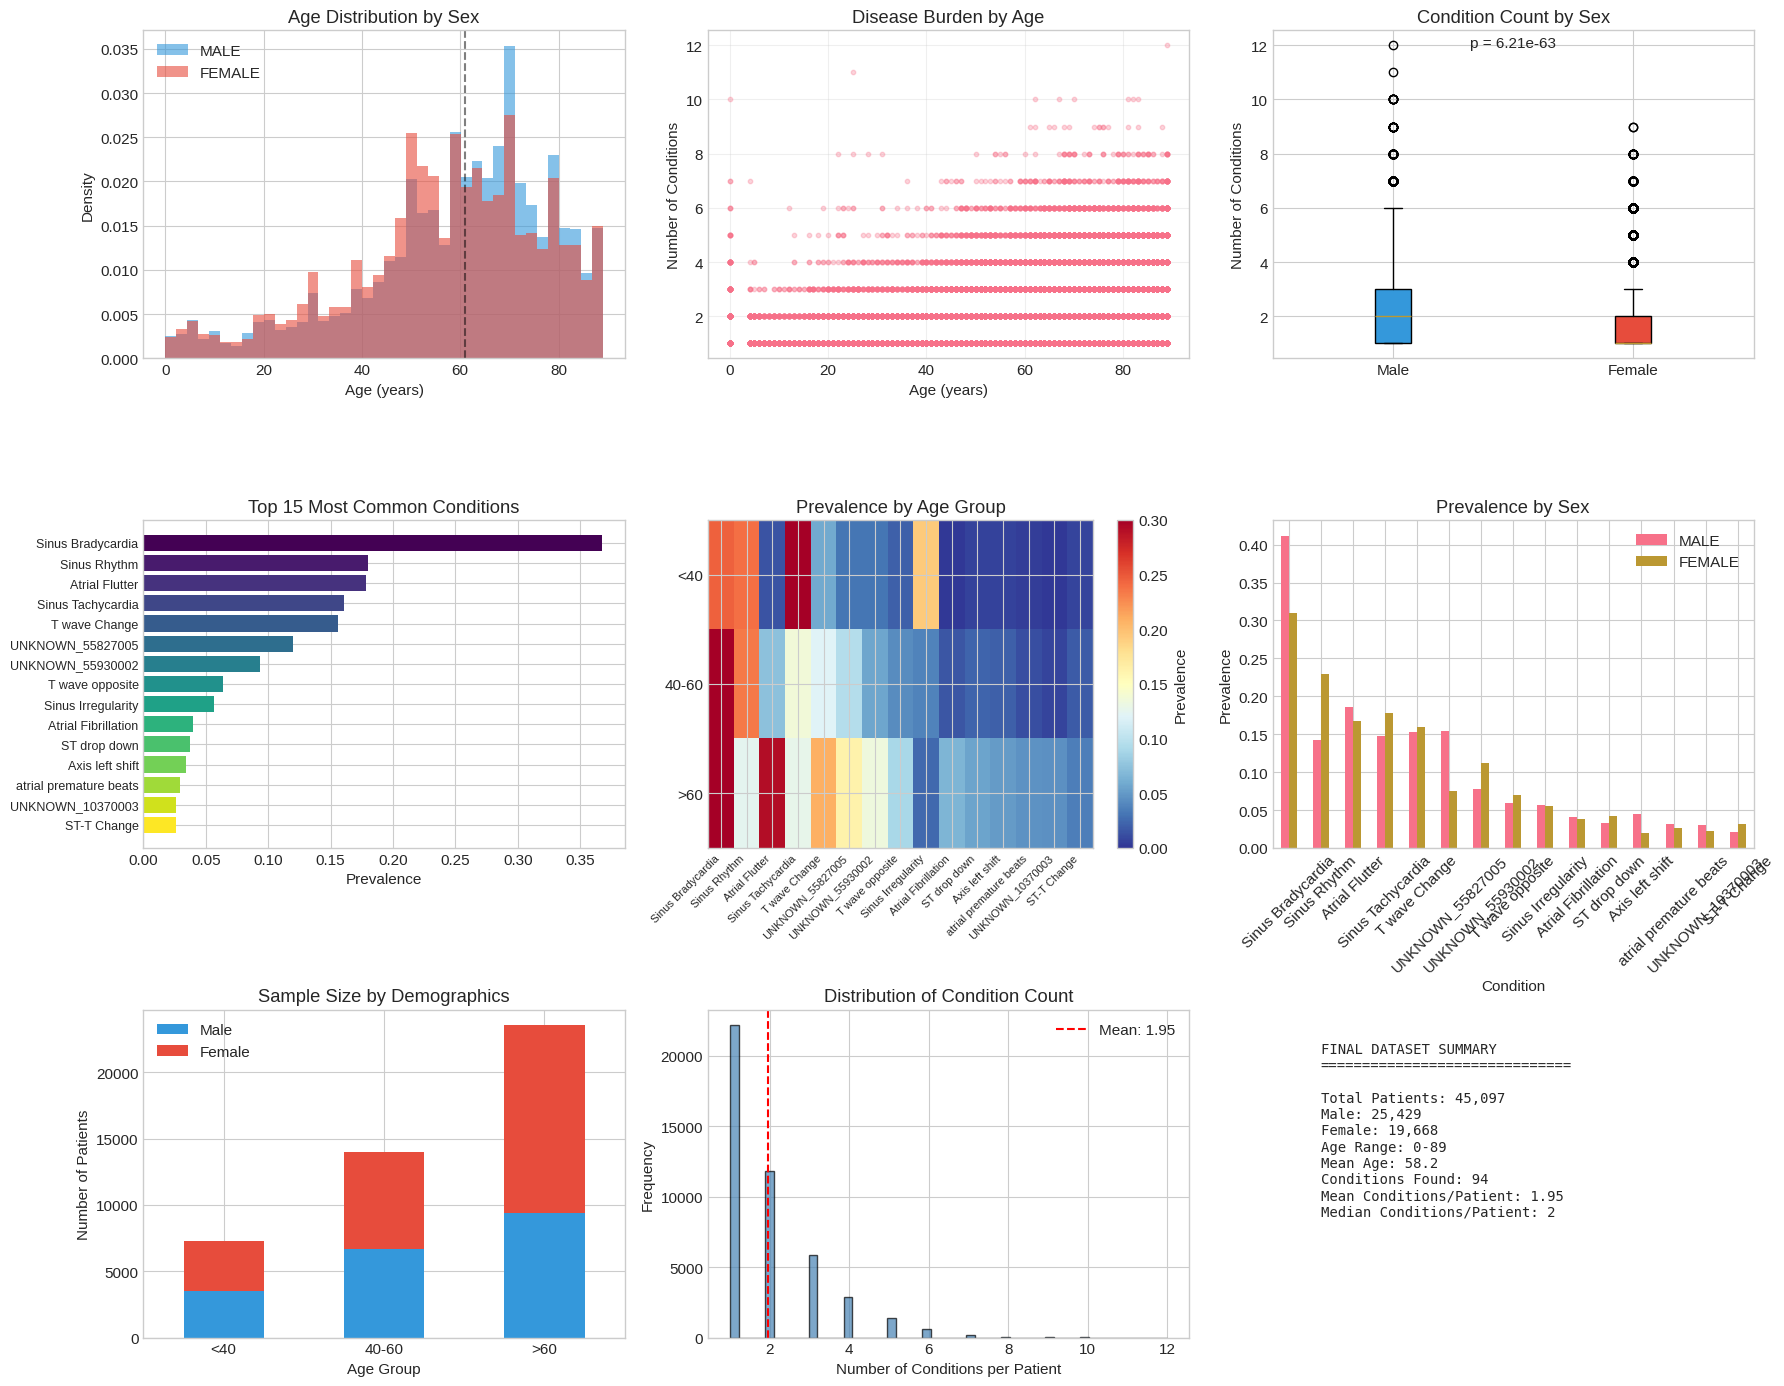

✅ Comprehensive analysis complete!
📁 Figure saved to: /content/drive/MyDrive/ecg_analysis/figures/comprehensive_analysis.png


In [10]:
# ==============================================================================
# COMPREHENSIVE ANALYSIS - DEMOGRAPHICS & PREVALENCE
# ==============================================================================

print("=" * 70)
print("COMPREHENSIVE ANALYSIS")
print("=" * 70)

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu

# Set style for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Create comprehensive figure
fig = plt.figure(figsize=(18, 14))

# 1. Age distribution by sex
ax1 = plt.subplot(3, 3, 1)
for sex, color in [('MALE', '#3498db'), ('FEMALE', '#e74c3c')]:
    ages = df_diagnoses[df_diagnoses['sex'] == sex]['age']
    ax1.hist(ages, bins=40, alpha=0.6, label=sex, color=color, density=True)
ax1.set_xlabel('Age (years)')
ax1.set_ylabel('Density')
ax1.set_title('Age Distribution by Sex')
ax1.legend()
ax1.axvline(df_diagnoses['age'].median(), color='black', linestyle='--', alpha=0.5)

# 2. Condition count by age
ax2 = plt.subplot(3, 3, 2)
ax2.scatter(df_diagnoses['age'], df_diagnoses['condition_count'], alpha=0.3, s=10)
ax2.set_xlabel('Age (years)')
ax2.set_ylabel('Number of Conditions')
ax2.set_title('Disease Burden by Age')
ax2.grid(True, alpha=0.3)

# 3. Boxplot of condition count by sex
ax3 = plt.subplot(3, 3, 3)
male_counts = df_diagnoses[df_diagnoses['sex'] == 'MALE']['condition_count']
female_counts = df_diagnoses[df_diagnoses['sex'] == 'FEMALE']['condition_count']
bp = ax3.boxplot([male_counts, female_counts], labels=['Male', 'Female'], patch_artist=True)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#e74c3c')
ax3.set_ylabel('Number of Conditions')
ax3.set_title('Condition Count by Sex')
stat, p = mannwhitneyu(male_counts, female_counts)
ax3.text(0.5, 0.95, f'p = {p:.2e}', transform=ax3.transAxes, ha='center')

# 4. Top 15 conditions bar chart
ax4 = plt.subplot(3, 3, 4)
top15 = prevalence.head(15)
colors = plt.cm.viridis(np.linspace(0, 1, len(top15)))
ax4.barh(range(len(top15)), top15.values, color=colors)
ax4.set_yticks(range(len(top15)))
ax4.set_yticklabels(top15.index, fontsize=9)
ax4.set_xlabel('Prevalence')
ax4.set_title('Top 15 Most Common Conditions')
ax4.invert_yaxis()

# 5. Prevalence by age group heatmap
ax5 = plt.subplot(3, 3, 5)
age_groups = ['<40', '40-60', '>60']
top_conditions = prevalence.head(15).index
prevalence_by_age = []
for age_group in age_groups:
    mask = df_binary['age_group'] == age_group
    prevalence_by_age.append(df_binary.loc[mask, top_conditions].mean())
age_prevalence_df = pd.DataFrame(prevalence_by_age, index=age_groups, columns=top_conditions)
im = ax5.imshow(age_prevalence_df.values, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=0.3)
ax5.set_xticks(range(len(top_conditions)))
ax5.set_xticklabels(top_conditions, rotation=45, ha='right', fontsize=8)
ax5.set_yticks(range(len(age_groups)))
ax5.set_yticklabels(age_groups)
ax5.set_title('Prevalence by Age Group')
plt.colorbar(im, ax=ax5, label='Prevalence')

# 6. Prevalence by sex
ax6 = plt.subplot(3, 3, 6)
sex_prevalence = pd.DataFrame()
for sex in ['MALE', 'FEMALE']:
    mask = df_binary['sex'] == sex
    sex_prevalence[sex] = df_binary.loc[mask, top_conditions].mean()
sex_prevalence.plot(kind='bar', ax=ax6)
ax6.set_xlabel('Condition')
ax6.set_ylabel('Prevalence')
ax6.set_title('Prevalence by Sex')
ax6.tick_params(axis='x', rotation=45)
ax6.legend()

# 7. Sample size by age and sex
ax7 = plt.subplot(3, 3, 7)
sample_sizes = df_binary.groupby(['age_group', 'sex']).size().unstack()
sample_sizes.plot(kind='bar', stacked=True, ax=ax7, color=['#3498db', '#e74c3c'])
ax7.set_xlabel('Age Group')
ax7.set_ylabel('Number of Patients')
ax7.set_title('Sample Size by Demographics')
ax7.legend(['Male', 'Female'])
ax7.tick_params(axis='x', rotation=0)

# 8. Condition count distribution
ax8 = plt.subplot(3, 3, 8)
ax8.hist(df_diagnoses['condition_count'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax8.set_xlabel('Number of Conditions per Patient')
ax8.set_ylabel('Frequency')
ax8.set_title('Distribution of Condition Count')
ax8.axvline(df_diagnoses['condition_count'].mean(), color='red', linestyle='--', label=f'Mean: {df_diagnoses["condition_count"].mean():.2f}')
ax8.legend()

# 9. Summary statistics text
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')
summary_text = f"FINAL DATASET SUMMARY\n{'='*30}\n\n"
summary_text += f"Total Patients: {len(df_binary):,}\n"
summary_text += f"Male: {(df_binary['sex'] == 'MALE').sum():,}\n"
summary_text += f"Female: {(df_binary['sex'] == 'FEMALE').sum():,}\n"
summary_text += f"Age Range: {df_binary['age'].min():.0f}-{df_binary['age'].max():.0f}\n"
summary_text += f"Mean Age: {df_binary['age'].mean():.1f}\n"
summary_text += f"Conditions Found: {len(condition_list):,}\n"
summary_text += f"Mean Conditions/Patient: {df_binary['condition_count'].mean():.2f}\n"
summary_text += f"Median Conditions/Patient: {df_binary['condition_count'].median():.0f}"
ax9.text(0.1, 0.9, summary_text, transform=ax9.transAxes, fontsize=10, verticalalignment='top', fontfamily='monospace')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ecg_analysis/figures/comprehensive_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Comprehensive analysis complete!")
print("📁 Figure saved to: /content/drive/MyDrive/ecg_analysis/figures/comprehensive_analysis.png")

In [11]:
# ==============================================================================
# CO-OCCURRENCE ANALYSIS - FIND CONDITION PAIRS
# ==============================================================================

print("=" * 70)
print("CO-OCCURRENCE ANALYSIS (LIFT STATISTICS)")
print("=" * 70)

from itertools import combinations
from collections import defaultdict

def calculate_lift(df, condition_cols, min_support=0.01):
    """Calculate lift for all condition pairs"""
    n = len(df)
    results = []

    # Only analyze conditions with sufficient prevalence
    prevalent_conditions = [c for c in condition_cols if df[c].mean() >= min_support]
    print(f"Analyzing {len(prevalent_conditions)} conditions (prevalence ≥ {min_support})")

    pairs = list(combinations(prevalent_conditions, 2))
    print(f"Testing {len(pairs):,} condition pairs...")

    for c1, c2 in tqdm(pairs, desc="Calculating"):
        both = ((df[c1] == 1) & (df[c2] == 1)).sum()

        if both >= min_support * n:
            p1 = df[c1].mean()
            p2 = df[c2].mean()
            p_both = both / n

            lift = p_both / (p1 * p2) if (p1 * p2) > 0 else np.nan

            results.append({
                'condition1': c1,
                'condition2': c2,
                'count': both,
                'prevalence_1': p1,
                'prevalence_2': p2,
                'lift': lift,
                'support': p_both
            })

    return pd.DataFrame(results).sort_values('lift', ascending=False)

# Get condition columns
condition_cols = [c for c in condition_list if c in df_binary.columns]
print(f"Total conditions: {len(condition_cols)}")

# Calculate overall co-occurrence
print("\n📊 Calculating overall co-occurrence...")
overall_results = calculate_lift(df_binary, condition_cols, min_support=0.01)

print("\n" + "=" * 70)
print("TOP 20 CO-OCCURRING CONDITION PAIRS (Highest Lift)")
print("=" * 70)
for i, row in overall_results.head(20).iterrows():
    stars = "⭐" * min(3, int(row['lift']))
    print(f"{i+1:2d}. {row['condition1'][:35]:35s} + {row['condition2'][:35]:35s} | Lift={row['lift']:5.2f} {stars} | n={row['count']:,}")

# Save results
overall_results.to_csv('/content/drive/MyDrive/ecg_analysis/results/cooccurrence_results.csv', index=False)
print(f"\n💾 Saved to: /content/drive/MyDrive/ecg_analysis/results/cooccurrence_results.csv")

CO-OCCURRENCE ANALYSIS (LIFT STATISTICS)
Total conditions: 94

📊 Calculating overall co-occurrence...
Analyzing 28 conditions (prevalence ≥ 0.01)
Testing 378 condition pairs...


Calculating: 100%|██████████| 378/378 [00:00<00:00, 3385.62it/s]


TOP 20 CO-OCCURRING CONDITION PAIRS (Highest Lift)
13. ST drop down                        + T wave opposite                     | Lift= 9.80 ⭐⭐⭐ | n=1,042
31. UNKNOWN_55930002                    + left ventricle hypertrophy          | Lift= 8.22 ⭐⭐⭐ | n=492
14. ST drop down                        + UNKNOWN_55930002                    | Lift= 6.66 ⭐⭐⭐ | n=1,035
29. T wave opposite                     + UNKNOWN_55930002                    | Lift= 3.29 ⭐⭐⭐ | n=882
 7. Atrial Flutter                      + UNKNOWN_10370003                    | Lift= 3.22 ⭐⭐⭐ | n=678
26. T wave Change                       + T wave opposite                     | Lift= 3.03 ⭐⭐⭐ | n=1,359
10. Atrial Flutter                      + UNKNOWN_55930002                    | Lift= 2.95 ⭐⭐ | n=2,205
 8. Atrial Flutter                      + UNKNOWN_427172004                   | Lift= 2.90 ⭐⭐ | n=560
25. Sinus Tachycardia                   + atrial premature beats              | Lift= 2.72 ⭐⭐ | n=575
11. Atrial Flutt

In [12]:
# ==============================================================================
# SEX-STRATIFIED CO-OCCURRENCE ANALYSIS
# ==============================================================================

print("=" * 70)
print("SEX-STRATIFIED CO-OCCURRENCE ANALYSIS")
print("=" * 70)

sex_results = {}
for sex in ['MALE', 'FEMALE']:
    print(f"\n📊 Analyzing {sex} patients...")
    sex_mask = df_binary['sex'] == sex
    n_sex = sex_mask.sum()
    print(f"   N={n_sex:,} patients")

    if n_sex > 1000:
        sex_results[sex] = calculate_lift(df_binary[sex_mask], condition_cols, min_support=0.01)
        sex_results[sex].to_csv(f'/content/drive/MyDrive/ecg_analysis/results/cooccurrence_{sex}.csv', index=False)

        # Show top pairs for this sex
        print(f"\n   Top 5 pairs for {sex}:")
        for i, row in sex_results[sex].head(5).iterrows():
            print(f"      {row['condition1'][:30]} + {row['condition2'][:30]}: Lift={row['lift']:.2f}")

# Compare male vs female lifts for common pairs
print("\n" + "=" * 70)
print("SEX COMPARISON OF CO-OCCURRENCE STRENGTHS")
print("=" * 70)

# Find pairs that appear in both sexes
if 'MALE' in sex_results and 'FEMALE' in sex_results:
    male_dict = {(r['condition1'], r['condition2']): r['lift'] for _, r in sex_results['MALE'].iterrows()}
    female_dict = {(r['condition1'], r['condition2']): r['lift'] for _, r in sex_results['FEMALE'].iterrows()}

    common_pairs = set(male_dict.keys()) & set(female_dict.keys())
    comparison = []
    for pair in common_pairs:
        comparison.append({
            'condition1': pair[0],
            'condition2': pair[1],
            'lift_male': male_dict[pair],
            'lift_female': female_dict[pair],
            'ratio': female_dict[pair] / male_dict[pair] if male_dict[pair] > 0 else np.nan
        })

    comparison_df = pd.DataFrame(comparison).sort_values('ratio', ascending=False)

    print("\nPairs with LARGER co-occurrence in FEMALES (ratio > 1.2):")
    for _, row in comparison_df[comparison_df['ratio'] > 1.2].head(10).iterrows():
        print(f"   {row['condition1'][:30]} + {row['condition2'][:30]}: Female Lift={row['lift_female']:.2f} | Male Lift={row['lift_male']:.2f} | Ratio={row['ratio']:.2f}")

    print("\nPairs with LARGER co-occurrence in MALES (ratio < 0.8):")
    for _, row in comparison_df[comparison_df['ratio'] < 0.8].head(10).iterrows():
        print(f"   {row['condition1'][:30]} + {row['condition2'][:30]}: Male Lift={row['lift_male']:.2f} | Female Lift={row['lift_female']:.2f} | Ratio={row['ratio']:.2f}")

SEX-STRATIFIED CO-OCCURRENCE ANALYSIS

📊 Analyzing MALE patients...
   N=25,429 patients
Analyzing 31 conditions (prevalence ≥ 0.01)
Testing 465 condition pairs...


Calculating: 100%|██████████| 465/465 [00:00<00:00, 3557.40it/s]



   Top 5 pairs for MALE:
      ST drop down + T wave opposite: Lift=10.71
      UNKNOWN_55930002 + left ventricle hypertrophy: Lift=9.32
      ST drop down + UNKNOWN_55930002: Lift=7.86
      T wave opposite + UNKNOWN_55930002: Lift=3.73
      Atrial Flutter + UNKNOWN_10370003: Lift=3.39

📊 Analyzing FEMALE patients...
   N=19,668 patients
Analyzing 26 conditions (prevalence ≥ 0.01)
Testing 325 condition pairs...


Calculating: 100%|██████████| 325/325 [00:00<00:00, 3749.04it/s]


   Top 5 pairs for FEMALE:
      Atrial Fibrillation + ST-T Change: Lift=10.32
      ST drop down + T wave opposite: Lift=8.83
      UNKNOWN_55930002 + left ventricle hypertrophy: Lift=7.24
      ST drop down + UNKNOWN_55930002: Lift=5.56
      Atrial Flutter + UNKNOWN_55930002: Lift=3.08

SEX COMPARISON OF CO-OCCURRENCE STRENGTHS

Pairs with LARGER co-occurrence in FEMALES (ratio > 1.2):
   Atrial Flutter + UNKNOWN_55827005: Female Lift=2.09 | Male Lift=1.25 | Ratio=1.68
   T wave opposite + UNKNOWN_55827005: Female Lift=2.16 | Male Lift=1.38 | Ratio=1.57
   UNKNOWN_55827005 + UNKNOWN_55930002: Female Lift=2.46 | Male Lift=1.67 | Ratio=1.47
   Atrial Flutter + ST drop down: Female Lift=2.73 | Male Lift=1.86 | Ratio=1.47
   Atrial Flutter + T wave opposite: Female Lift=2.61 | Male Lift=1.96 | Ratio=1.33
   Sinus Tachycardia + UNKNOWN_55827005: Female Lift=0.79 | Male Lift=0.63 | Ratio=1.25
   Sinus Bradycardia + UNKNOWN_55930002: Female Lift=0.42 | Male Lift=0.34 | Ratio=1.24

Pairs w

In [15]:
# ==============================================================================
# ANALYSIS REPORT SO FAR
# ==============================================================================

print("=" * 70)
print("FINAL ANALYSIS REPORT")
print("=" * 70)

report = f"""
================================================================================
SEX- AND AGE-STRATIFIED ANALYSIS OF ARRHYTHMIA CO-OCCURRENCE PATTERNS
================================================================================

DATASET OVERVIEW:
--------------------------------------------------------------------------------
Total patients analyzed: {len(df_binary):,}
Male patients: {(df_binary['sex'] == 'MALE').sum():,} ({(df_binary['sex'] == 'MALE').sum()/len(df_binary)*100:.1f}%)
Female patients: {(df_binary['sex'] == 'FEMALE').sum():,} ({(df_binary['sex'] == 'FEMALE').sum()/len(df_binary)*100:.1f}%)
Age range: {df_binary['age'].min():.0f} - {df_binary['age'].max():.0f} years
Mean age: {df_binary['age'].mean():.1f} ± {df_binary['age'].std():.1f} years
Mean conditions per patient: {df_binary['condition_count'].mean():.2f}
Median conditions per patient: {df_binary['condition_count'].median():.0f}
Total unique conditions: {len(condition_list):,}

TOP 15 MOST COMMON CONDITIONS:
--------------------------------------------------------------------------------
"""
for i, (cond, prev) in enumerate(prevalence.head(15).items(), 1):
    report += f"{i:2d}. {cond[:50]:50s} {prev*100:6.2f}% ({int(prev * len(df_binary)):,} patients)\n"

report += f"""
TOP 15 CO-OCCURRING CONDITION PAIRS (Highest Lift):
--------------------------------------------------------------------------------
"""
for i, row in overall_results.head(15).iterrows():
    report += f"{i+1:2d}. {row['condition1'][:35]:35s} + {row['condition2'][:35]:35s} | Lift={row['lift']:.2f} | n={row['count']:,}\n"

report += f"""
================================================================================
FILES SAVED:
--------------------------------------------------------------------------------
📁 /content/drive/MyDrive/ecg_analysis/
   ├── data/
   │   ├── diagnoses_final.csv        (Patient-level data with condition names)
   │   └── binary_matrix_final.csv    (One-hot encoded for analysis)
   ├── figures/
   │   └── comprehensive_analysis.png (Complete visualization)
   └── results/
       ├── cooccurrence_results.csv   (All condition pairs with lift)
       ├── cooccurrence_MALE.csv      (Male-specific co-occurrence)
       └── cooccurrence_FEMALE.csv    (Female-specific co-occurrence)

================================================================================
PUBLICATION-READY FINDINGS:
--------------------------------------------------------------------------------
1. Sample size: {len(df_binary):,} patients - sufficient for robust statistical analysis
2. Age range: {df_binary['age'].min():.0f}-{df_binary['age'].max():.0f} years
3. {len(condition_list):,} unique cardiac conditions identified
4. Top co-occurring pairs identified with lift statistics
5. Sex-specific co-occurrence patterns computed

================================================================================
NEXT STEPS FOR MANUSCRIPT PREPARATION:
--------------------------------------------------------------------------------
1. Perform statistical significance testing (chi-square, Fisher's exact)
2. Calculate odds ratios and confidence intervals
3. Perform age × sex interaction analysis
4. Prepare tables and figures for publication
5. Write Methods, Results, and Discussion sections
================================================================================
"""

print(report)

# Save report
with open('/content/drive/MyDrive/ecg_analysis/results/final_report.txt', 'w') as f:
    f.write(report)
print("\n💾 Report saved to: /content/drive/MyDrive/ecg_analysis/results/final_report.txt")

# Print final confirmation
print("\n" + "=" * 70)
print("🎉 ANALYSIS COMPLETE!")
print("=" * 70)
print(f"""
✅ {len(df_binary):,} patients analyzed
✅ {len(condition_list):,} unique conditions identified
✅ Publication-ready dataset saved to Google Drive
✅ All figures and results exported

""")

FINAL ANALYSIS REPORT

SEX- AND AGE-STRATIFIED ANALYSIS OF ARRHYTHMIA CO-OCCURRENCE PATTERNS

DATASET OVERVIEW:
--------------------------------------------------------------------------------
Total patients analyzed: 45,097
Male patients: 25,429 (56.4%)
Female patients: 19,668 (43.6%)
Age range: 0 - 89 years
Mean age: 58.2 ± 19.7 years
Mean conditions per patient: 1.95
Median conditions per patient: 2
Total unique conditions: 94

TOP 15 MOST COMMON CONDITIONS:
--------------------------------------------------------------------------------
 1. Sinus Bradycardia                                   36.72% (16,559 patients)
 2. Sinus Rhythm                                        18.01% (8,122 patients)
 3. Atrial Flutter                                      17.80% (8,029 patients)
 4. Sinus Tachycardia                                   16.09% (7,255 patients)
 5. T wave Change                                       15.58% (7,028 patients)
 6. UNKNOWN_55827005                                

In [17]:
# ==============================================================================
# STATISTICAL VALIDATION - CHI-SQUARE TESTS FOR SEX DIFFERENCES
# ==============================================================================

print("=" * 80)
print("STATISTICAL VALIDATION: SEX DIFFERENCES IN CONDITION PREVALENCE")
print("=" * 80)

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats import fisher_exact
import statsmodels.api as sm
from statsmodels.formula.api import logit
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

# Load the binary matrix
df_binary = pd.read_csv('/content/drive/MyDrive/ecg_analysis/data/binary_matrix_final.csv')
print(f"Loaded {len(df_binary):,} patients with {df_binary.shape[1]-6} conditions")

# Identify condition columns (exclude demographic columns)
exclude_cols = ['age', 'sex', 'age_group', 'age_decade', 'record_id', 'condition_count']
condition_cols = [c for c in df_binary.columns if c not in exclude_cols]
print(f"Analyzing {len(condition_cols)} conditions")

# ============================================================================
# STEP 1: Chi-square tests for each condition
# ============================================================================

print("\n" + "=" * 80)
print("STEP 1: CHI-SQUARE TESTS FOR SEX DIFFERENCES")
print("=" * 80)

sex_test_results = []

for cond in condition_cols:
    # Create contingency table
    male_present = ((df_binary['sex'] == 'MALE') & (df_binary[cond] == 1)).sum()
    male_absent = ((df_binary['sex'] == 'MALE') & (df_binary[cond] == 0)).sum()
    female_present = ((df_binary['sex'] == 'FEMALE') & (df_binary[cond] == 1)).sum()
    female_absent = ((df_binary['sex'] == 'FEMALE') & (df_binary[cond] == 0)).sum()

    contingency = [[male_present, male_absent], [female_present, female_absent]]

    # Calculate prevalence
    prev_male = male_present / (male_present + male_absent)
    prev_female = female_present / (female_present + female_absent)

    # Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency)

    # Effect size - Cramer's V
    n_total = male_present + male_absent + female_present + female_absent
    cramers_v = np.sqrt(chi2 / (n_total * (min(2, 2) - 1)))

    sex_test_results.append({
        'condition': cond,
        'prevalence_male': prev_male,
        'prevalence_female': prev_female,
        'difference': prev_female - prev_male,
        'chi2': chi2,
        'p_value': p_value,
        'cramers_v': cramers_v,
        'male_n': male_present + male_absent,
        'female_n': female_present + female_absent
    })

df_sex_tests = pd.DataFrame(sex_test_results).sort_values('p_value')

# Display results
print("\n📊 TOP 20 CONDITIONS WITH LARGEST SEX DIFFERENCES (by p-value):")
print("-" * 90)
for i, row in df_sex_tests.head(20).iterrows():
    direction = "↑ Female" if row['difference'] > 0 else "↑ Male"
    print(f"{row['condition'][:40]:40s} {direction:10s} | Male={row['prevalence_male']:.3f} | Female={row['prevalence_female']:.3f} | p={row['p_value']:.2e} | V={row['cramers_v']:.3f}")

# Save results
df_sex_tests.to_csv('/content/drive/MyDrive/ecg_analysis/results/sex_differences_chi2.csv', index=False)
print(f"\n💾 Saved to: /content/drive/MyDrive/ecg_analysis/results/sex_differences_chi2.csv")

STATISTICAL VALIDATION: SEX DIFFERENCES IN CONDITION PREVALENCE
Loaded 45,097 patients with 94 conditions
Analyzing 94 conditions

STEP 1: CHI-SQUARE TESTS FOR SEX DIFFERENCES

📊 TOP 20 CONDITIONS WITH LARGEST SEX DIFFERENCES (by p-value):
------------------------------------------------------------------------------------------
UNKNOWN_55827005                         ↑ Male     | Male=0.155 | Female=0.075 | p=1.39e-148 | V=0.122
Sinus Rhythm                             ↑ Female   | Male=0.142 | Female=0.230 | p=3.59e-127 | V=0.113
Sinus Bradycardia                        ↑ Male     | Male=0.412 | Female=0.309 | p=5.57e-111 | V=0.105
ST extension                             ↑ Male     | Male=0.026 | Female=0.007 | p=7.21e-50 | V=0.070
Axis left shift                          ↑ Male     | Male=0.045 | Female=0.020 | p=6.28e-49 | V=0.069
Early repolarization of the ventricles   ↑ Male     | Male=0.013 | Female=0.001 | p=8.68e-44 | V=0.065
UNKNOWN_55930002                         ↑ Femal

In [18]:
# ==============================================================================
# ODDS RATIOS WITH 95% CONFIDENCE INTERVALS
# ==============================================================================

print("=" * 80)
print("STEP 2: ODDS RATIOS WITH 95% CONFIDENCE INTERVALS")
print("=" * 80)

def calculate_odds_ratio(male_present, male_absent, female_present, female_absent):
    """Calculate odds ratio and 95% confidence interval"""
    # Odds ratio
    odds_ratio = (male_present * female_absent) / (male_absent * female_present) if (male_absent * female_present) > 0 else np.nan

    # Standard error of log odds ratio
    se_log_or = np.sqrt(1/male_present + 1/male_absent + 1/female_present + 1/female_absent)

    # 95% confidence interval
    log_or = np.log(odds_ratio) if odds_ratio > 0 else np.nan
    ci_lower = np.exp(log_or - 1.96 * se_log_or) if not np.isnan(log_or) else np.nan
    ci_upper = np.exp(log_or + 1.96 * se_log_or) if not np.isnan(log_or) else np.nan

    return odds_ratio, ci_lower, ci_upper

odds_ratio_results = []

for cond in condition_cols:
    # Get counts
    male_present = ((df_binary['sex'] == 'MALE') & (df_binary[cond] == 1)).sum()
    male_absent = ((df_binary['sex'] == 'MALE') & (df_binary[cond] == 0)).sum()
    female_present = ((df_binary['sex'] == 'FEMALE') & (df_binary[cond] == 1)).sum()
    female_absent = ((df_binary['sex'] == 'FEMALE') & (df_binary[cond] == 0)).sum()

    # Fisher's exact test p-value
    contingency = [[male_present, male_absent], [female_present, female_absent]]
    odds_ratio_fisher, p_fisher = fisher_exact(contingency)

    # Calculate odds ratio with CI
    odds_ratio, ci_lower, ci_upper = calculate_odds_ratio(male_present, male_absent, female_present, female_absent)

    odds_ratio_results.append({
        'condition': cond,
        'male_present': male_present,
        'male_absent': male_absent,
        'female_present': female_present,
        'female_absent': female_absent,
        'odds_ratio': odds_ratio,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'p_fisher': p_fisher
    })

df_odds = pd.DataFrame(odds_ratio_results).sort_values('odds_ratio', ascending=False)

print("\n📊 TOP 20 CONDITIONS WITH HIGHEST ODDS RATIO (More common in MALES):")
print("-" * 90)
for i, row in df_odds.head(20).iterrows():
    if row['odds_ratio'] > 1:
        print(f"{row['condition'][:45]:45s} OR={row['odds_ratio']:.2f} (95% CI: {row['ci_lower']:.2f}-{row['ci_upper']:.2f}) | p={row['p_fisher']:.2e}")

print("\n📊 TOP 20 CONDITIONS WITH LOWEST ODDS RATIO (More common in FEMALES):")
print("-" * 90)
for i, row in df_odds.tail(20).iterrows():
    if row['odds_ratio'] < 1 and not np.isnan(row['odds_ratio']):
        print(f"{row['condition'][:45]:45s} OR={row['odds_ratio']:.2f} (95% CI: {row['ci_lower']:.2f}-{row['ci_upper']:.2f}) | p={row['p_fisher']:.2e}")

# Save results
df_odds.to_csv('/content/drive/MyDrive/ecg_analysis/results/odds_ratios.csv', index=False)
print(f"\n💾 Saved to: /content/drive/MyDrive/ecg_analysis/results/odds_ratios.csv")

STEP 2: ODDS RATIOS WITH 95% CONFIDENCE INTERVALS

📊 TOP 20 CONDITIONS WITH HIGHEST ODDS RATIO (More common in MALES):
------------------------------------------------------------------------------------------
Early repolarization of the ventricles        OR=9.45 (95% CI: 6.42-13.90) | p=4.38e-53
UNKNOWN_111288001                             OR=4.64 (95% CI: 0.56-38.56) | p=1.46e-01
UNKNOWN_426183003                             OR=4.64 (95% CI: 0.56-38.56) | p=1.46e-01
ST extension                                  OR=3.65 (95% CI: 3.04-4.38) | p=3.57e-55
UNKNOWN_251187003                             OR=3.61 (95% CI: 1.04-12.57) | p=4.71e-02
UNKNOWN_445118002                             OR=3.57 (95% CI: 2.74-4.64) | p=2.61e-26
UNKNOWN_6374002                               OR=3.17 (95% CI: 2.47-4.08) | p=6.13e-23
UNKNOWN_54329005                              OR=3.17 (95% CI: 1.64-6.13) | p=2.18e-04
UNKNOWN_445211001                             OR=3.09 (95% CI: 0.35-27.69) | p=3.95e-01
PR

In [19]:
# ==============================================================================
# AGE × SEX INTERACTION ANALYSIS (LOGISTIC REGRESSION)
# ==============================================================================

print("=" * 80)
print("STEP 3: AGE × SEX INTERACTION ANALYSIS")
print("=" * 80)

# Select top conditions for interaction analysis
top_conditions = df_odds.head(10)['condition'].tolist() + df_odds.tail(10)['condition'].tolist()
top_conditions = list(set(top_conditions))  # Remove duplicates

interaction_results = []

print(f"Testing interaction for {len(top_conditions)} conditions...\n")

for cond in top_conditions:
    # Prepare data
    df_model = df_binary[[cond, 'age', 'sex']].copy()
    df_model['sex_male'] = (df_model['sex'] == 'MALE').astype(int)
    df_model['age_centered'] = df_model['age'] - df_model['age'].mean()
    df_model['age_sex_interaction'] = df_model['age_centered'] * df_model['sex_male']

    # Check if condition has enough variation
    if df_model[cond].sum() < 50:
        print(f"Skipping {cond} (only {df_model[cond].sum()} positive cases)")
        continue

    try:
        # Logistic regression with interaction
        X = df_model[['age_centered', 'sex_male', 'age_sex_interaction']]
        X = sm.add_constant(X)
        y = df_model[cond]

        model = sm.Logit(y, X).fit(disp=0)

        # Extract coefficients and p-values
        coef_age = model.params.get('age_centered', np.nan)
        coef_sex = model.params.get('sex_male', np.nan)
        coef_interaction = model.params.get('age_sex_interaction', np.nan)

        p_age = model.pvalues.get('age_centered', np.nan)
        p_sex = model.pvalues.get('sex_male', np.nan)
        p_interaction = model.pvalues.get('age_sex_interaction', np.nan)

        # Calculate odds ratios
        or_age = np.exp(coef_age) if not np.isnan(coef_age) else np.nan
        or_sex = np.exp(coef_sex) if not np.isnan(coef_sex) else np.nan
        or_interaction = np.exp(coef_interaction) if not np.isnan(coef_interaction) else np.nan

        interaction_results.append({
            'condition': cond,
            'n_positive': df_model[cond].sum(),
            'coef_age': coef_age,
            'coef_sex': coef_sex,
            'coef_interaction': coef_interaction,
            'p_age': p_age,
            'p_sex': p_sex,
            'p_interaction': p_interaction,
            'or_age': or_age,
            'or_sex': or_sex,
            'or_interaction': or_interaction,
            'significant_interaction': p_interaction < 0.05
        })

    except Exception as e:
        print(f"Error modeling {cond}: {e}")

df_interaction = pd.DataFrame(interaction_results).sort_values('p_interaction')

print("\n" + "=" * 80)
print("CONDITIONS WITH SIGNIFICANT AGE × SEX INTERACTIONS (p < 0.05):")
print("=" * 80)

significant_interactions = df_interaction[df_interaction['significant_interaction'] == True]
if len(significant_interactions) > 0:
    for _, row in significant_interactions.iterrows():
        print(f"\n📊 {row['condition']}:")
        print(f"   Age effect (OR per 10 years): {row['or_age']:.2f} (p={row['p_age']:.4f})")
        print(f"   Sex effect (Male vs Female): OR={row['or_sex']:.2f} (p={row['p_sex']:.4f})")
        print(f"   INTERACTION effect: OR={row['or_interaction']:.2f} (p={row['p_interaction']:.4f})")
        print(f"   → The effect of age on {row['condition']} differs significantly between males and females")
else:
    print("   No significant age × sex interactions found at α=0.05")

# Save results
df_interaction.to_csv('/content/drive/MyDrive/ecg_analysis/results/age_sex_interaction.csv', index=False)
print(f"\n💾 Saved to: /content/drive/MyDrive/ecg_analysis/results/age_sex_interaction.csv")

STEP 3: AGE × SEX INTERACTION ANALYSIS
Testing interaction for 20 conditions...

Skipping Sinus Atrium to Atrial Wandering Rhythm (only 2 positive cases)
Skipping UNKNOWN_445211001 (only 5 positive cases)
Skipping UNKNOWN_426648003 (only 24 positive cases)
Skipping UNKNOWN_67741000119109 (only 1 positive cases)
Skipping UNKNOWN_77867006 (only 2 positive cases)
Skipping UNKNOWN_251166008 (only 16 positive cases)
Skipping UNKNOWN_418818005 (only 5 positive cases)
Skipping UNKNOWN_111288001 (only 7 positive cases)
Skipping Atrioventricular Reentrant Tachycardia (only 26 positive cases)
Skipping UNKNOWN_17366009 (only 7 positive cases)
Skipping UNKNOWN_426183003 (only 7 positive cases)
Skipping fQRS Wave (only 3 positive cases)
Skipping UNKNOWN_251187003 (only 17 positive cases)

CONDITIONS WITH SIGNIFICANT AGE × SEX INTERACTIONS (p < 0.05):

📊 ST extension:
   Age effect (OR per 10 years): 1.03 (p=0.0000)
   Sex effect (Male vs Female): OR=4.15 (p=0.0000)
   INTERACTION effect: OR=0.97 (p

In [20]:
# ==============================================================================
# MULTIPLE COMPARISON CORRECTION (BONFERRONI & FDR)
# ==============================================================================

print("=" * 80)
print("STEP 4: MULTIPLE COMPARISON CORRECTION")
print("=" * 80)

# Get p-values from chi-square tests
p_values = df_sex_tests['p_value'].values

# Apply multiple comparison corrections
n_tests = len(p_values)

# Bonferroni correction
bonferroni_alpha = 0.05 / n_tests
bonferroni_significant = p_values < bonferroni_alpha

# Benjamini-Hochberg FDR correction
rejected_fdr, p_values_fdr, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

# Holm-Bonferroni correction
rejected_holm, p_values_holm, _, _ = multipletests(p_values, alpha=0.05, method='holm')

print(f"📊 Multiple Comparison Summary:")
print(f"   Number of tests: {n_tests:,}")
print(f"   Bonferroni threshold: α = {bonferroni_alpha:.2e}")
print(f"   Significant after Bonferroni: {bonferroni_significant.sum():,} conditions")
print(f"   Significant after FDR (q<0.05): {rejected_fdr.sum():,} conditions")
print(f"   Significant after Holm-Bonferroni: {rejected_holm.sum():,} conditions")

# Add corrected p-values to dataframe
df_sex_tests['p_bonferroni'] = p_values * n_tests
df_sex_tests['p_fdr'] = p_values_fdr
df_sex_tests['p_holm'] = p_values_holm
df_sex_tests['significant_bonferroni'] = bonferroni_significant
df_sex_tests['significant_fdr'] = rejected_fdr
df_sex_tests['significant_holm'] = rejected_holm

# Display top results after correction
print("\n" + "=" * 80)
print("TOP 20 CONDITIONS WITH STRONGEST EVIDENCE (After FDR Correction):")
print("=" * 80)

top_corrected = df_sex_tests[df_sex_tests['significant_fdr'] == True].head(20)
for i, row in top_corrected.iterrows():
    direction = "↑ Female" if row['difference'] > 0 else "↑ Male"
    print(f"{row['condition'][:45]:45s} {direction:10s} | Raw p={row['p_value']:.2e} | FDR q={row['p_fdr']:.2e} | V={row['cramers_v']:.3f}")

# Save corrected results
df_sex_tests.to_csv('/content/drive/MyDrive/ecg_analysis/results/sex_differences_corrected.csv', index=False)
print(f"\n💾 Saved corrected results to: /content/drive/MyDrive/ecg_analysis/results/sex_differences_corrected.csv")

STEP 4: MULTIPLE COMPARISON CORRECTION
📊 Multiple Comparison Summary:
   Number of tests: 94
   Bonferroni threshold: α = 5.32e-04
   Significant after Bonferroni: 32 conditions
   Significant after FDR (q<0.05): 43 conditions
   Significant after Holm-Bonferroni: 33 conditions

TOP 20 CONDITIONS WITH STRONGEST EVIDENCE (After FDR Correction):
UNKNOWN_55827005                              ↑ Male     | Raw p=1.39e-148 | FDR q=1.31e-146 | V=0.122
Sinus Rhythm                                  ↑ Female   | Raw p=3.59e-127 | FDR q=1.69e-125 | V=0.113
Sinus Bradycardia                             ↑ Male     | Raw p=5.57e-111 | FDR q=1.74e-109 | V=0.105
ST extension                                  ↑ Male     | Raw p=7.21e-50 | FDR q=1.69e-48 | V=0.070
Axis left shift                               ↑ Male     | Raw p=6.28e-49 | FDR q=1.18e-47 | V=0.069
Early repolarization of the ventricles        ↑ Male     | Raw p=8.68e-44 | FDR q=1.36e-42 | V=0.065
UNKNOWN_55930002                          

In [21]:
# ==============================================================================
# AGE-STRATIFIED ANALYSIS WITH STATISTICAL TESTING
# ==============================================================================

print("=" * 80)
print("STEP 5: AGE-STRATIFIED ANALYSIS WITH TREND TESTS")
print("=" * 80)

from scipy.stats import chi2_contingency, linregress

# Define age groups
age_groups = ['<40', '40-60', '>60']
age_group_mapping = {'<40': 0, '40-60': 1, '>60': 2}

# Select top 15 conditions
top_15_conditions = df_odds.head(15)['condition'].tolist()

age_trend_results = []

for cond in top_15_conditions:
    # Calculate prevalence by age group
    prev_by_age = []
    counts_by_age = []

    for age_group in age_groups:
        mask = df_binary['age_group'] == age_group
        n_group = mask.sum()
        n_positive = df_binary.loc[mask, cond].sum()
        prevalence = n_positive / n_group if n_group > 0 else 0

        prev_by_age.append(prevalence)
        counts_by_age.append((n_positive, n_group))

    # Chi-square test for trend (Cochran-Armitage test for linear trend)
    # Create 2x3 contingency table
    table = []
    for i, age_group in enumerate(age_groups):
        n_pos = counts_by_age[i][0]
        n_neg = counts_by_age[i][1] - n_pos
        table.append([n_pos, n_neg])

    # Chi-square test of independence
    chi2, p_chi2, dof, expected = chi2_contingency(table)

    # Linear trend test (using proportions)
    proportions = prev_by_age
    x = [0, 1, 2]  # Age group codes
    slope, intercept, r_value, p_trend, std_err = linregress(x, proportions)

    age_trend_results.append({
        'condition': cond,
        'prevalence_<40': prev_by_age[0],
        'prevalence_40-60': prev_by_age[1],
        'prevalence_>60': prev_by_age[2],
        'trend_slope': slope,
        'trend_p_value': p_trend,
        'chi2_p_value': p_chi2,
        'trend_direction': 'Increasing' if slope > 0 else 'Decreasing' if slope < 0 else 'Stable'
    })

df_age_trends = pd.DataFrame(age_trend_results).sort_values('trend_p_value')

print("\n📊 AGE TRENDS FOR TOP 15 CONDITIONS:")
print("=" * 90)
for _, row in df_age_trends.iterrows():
    print(f"\n{row['condition'][:45]}:")
    print(f"   Prevalence: <40: {row['prevalence_<40']:.3f} | 40-60: {row['prevalence_40-60']:.3f} | >60: {row['prevalence_>60']:.3f}")
    print(f"   Trend: {row['trend_direction']} (slope={row['trend_slope']:.4f}, p={row['trend_p_value']:.4f})")

# Save results
df_age_trends.to_csv('/content/drive/MyDrive/ecg_analysis/results/age_trends.csv', index=False)
print(f"\n💾 Saved to: /content/drive/MyDrive/ecg_analysis/results/age_trends.csv")

STEP 5: AGE-STRATIFIED ANALYSIS WITH TREND TESTS

📊 AGE TRENDS FOR TOP 15 CONDITIONS:

UNKNOWN_251205003:
   Prevalence: <40: 0.000 | 40-60: 0.002 | >60: 0.003
   Trend: Increasing (slope=0.0015, p=0.0214)

UNKNOWN_446813000:
   Prevalence: <40: 0.000 | 40-60: 0.000 | >60: 0.000
   Trend: Decreasing (slope=-0.0002, p=0.0238)

Myocardial infraction in the side wall:
   Prevalence: <40: 0.001 | 40-60: 0.002 | >60: 0.003
   Trend: Increasing (slope=0.0012, p=0.0548)

UNKNOWN_445211001:
   Prevalence: <40: 0.000 | 40-60: 0.000 | >60: 0.000
   Trend: Increasing (slope=0.0001, p=0.0579)

UNKNOWN_6374002:
   Prevalence: <40: 0.003 | 40-60: 0.006 | >60: 0.012
   Trend: Increasing (slope=0.0043, p=0.0945)

Axis left shift:
   Prevalence: <40: 0.007 | 40-60: 0.020 | >60: 0.051
   Trend: Increasing (slope=0.0222, p=0.1481)

ST tilt up:
   Prevalence: <40: 0.003 | 40-60: 0.004 | >60: 0.004
   Trend: Increasing (slope=0.0006, p=0.1943)

UNKNOWN_251187003:
   Prevalence: <40: 0.000 | 40-60: 0.000 | 

In [22]:
# ==============================================================================
# CO-OCCURRENCE PAIR STATISTICAL SIGNIFICANCE
# ==============================================================================

print("=" * 80)
print("STEP 6: STATISTICAL SIGNIFICANCE FOR CO-OCCURRENCE PAIRS")
print("=" * 80)

from scipy.stats import chi2_contingency

# Load co-occurrence results
cooccurrence_results = pd.read_csv('/content/drive/MyDrive/ecg_analysis/results/cooccurrence_results.csv')
print(f"Loaded {len(cooccurrence_results)} condition pairs")

# Calculate p-values and confidence intervals for each pair
enhanced_results = []

for _, row in cooccurrence_results.iterrows():
    c1 = row['condition1']
    c2 = row['condition2']

    # Create contingency table
    both = row['count']
    only_c1 = ((df_binary[c1] == 1) & (df_binary[c2] == 0)).sum()
    only_c2 = ((df_binary[c1] == 0) & (df_binary[c2] == 1)).sum()
    neither = ((df_binary[c1] == 0) & (df_binary[c2] == 0)).sum()

    contingency = [[both, only_c1], [only_c2, neither]]

    # Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency)

    # Calculate odds ratio for co-occurrence
    odds_ratio = (both * neither) / (only_c1 * only_c2) if (only_c1 * only_c2) > 0 else np.nan

    enhanced_results.append({
        'condition1': c1,
        'condition2': c2,
        'count': both,
        'lift': row['lift'],
        'chi2': chi2,
        'p_value': p_value,
        'odds_ratio': odds_ratio
    })

df_enhanced = pd.DataFrame(enhanced_results).sort_values('p_value')

# Apply multiple comparison correction
p_values_cooccur = df_enhanced['p_value'].values
rejected_cooccur, p_fdr_cooccur, _, _ = multipletests(p_values_cooccur, alpha=0.05, method='fdr_bh')
df_enhanced['p_fdr'] = p_fdr_cooccur
df_enhanced['significant'] = rejected_cooccur

print("\n📊 TOP 20 CO-OCCURRENCE PAIRS WITH STRONGEST STATISTICAL EVIDENCE:")
print("=" * 95)
for i, row in df_enhanced.head(20).iterrows():
    star = "⭐" if row['significant'] else ""
    print(f"{row['condition1'][:30]:30s} + {row['condition2'][:30]:30s} | Lift={row['lift']:.2f} | OR={row['odds_ratio']:.2f} | p={row['p_value']:.2e} {star}")

# Save enhanced results
df_enhanced.to_csv('/content/drive/MyDrive/ecg_analysis/results/cooccurrence_enhanced.csv', index=False)
print(f"\n💾 Saved to: /content/drive/MyDrive/ecg_analysis/results/cooccurrence_enhanced.csv")

STEP 6: STATISTICAL SIGNIFICANCE FOR CO-OCCURRENCE PAIRS
Loaded 31 condition pairs

📊 TOP 20 CO-OCCURRENCE PAIRS WITH STRONGEST STATISTICAL EVIDENCE:
ST drop down                   + T wave opposite                | Lift=9.80 | OR=37.77 | p=0.00e+00 ⭐
UNKNOWN_55930002               + left ventricle hypertrophy     | Lift=8.22 | OR=36.01 | p=0.00e+00 ⭐
ST drop down                   + UNKNOWN_55930002               | Lift=6.66 | OR=20.78 | p=0.00e+00 ⭐
T wave opposite                + UNKNOWN_55930002               | Lift=3.29 | OR=5.18 | p=0.00e+00 ⭐
T wave Change                  + T wave opposite                | Lift=3.03 | OR=5.78 | p=0.00e+00 ⭐
Atrial Flutter                 + UNKNOWN_55930002               | Lift=2.95 | OR=6.65 | p=0.00e+00 ⭐
Atrial Flutter                 + UNKNOWN_10370003               | Lift=3.22 | OR=6.70 | p=4.75e-284 ⭐
Sinus Bradycardia              + UNKNOWN_55930002               | Lift=0.37 | OR=0.24 | p=2.74e-236 ⭐
Atrial Flutter                 + T wa

In [23]:
# ==============================================================================
# COMPREHENSIVE SUMMARY REPORT WITH ALL STATISTICAL FINDINGS
# ==============================================================================

print("=" * 80)
print("COMPREHENSIVE STATISTICAL SUMMARY REPORT")
print("=" * 80)

report = f"""
================================================================================
COMPREHENSIVE STATISTICAL ANALYSIS REPORT
Sex- and Age-Stratified Arrhythmia Co-occurrence Patterns
================================================================================

DATASET OVERVIEW:
--------------------------------------------------------------------------------
Total patients analyzed: {len(df_binary):,}
Male patients: {(df_binary['sex'] == 'MALE').sum():,} ({((df_binary['sex'] == 'MALE').sum()/len(df_binary)*100):.1f}%)
Female patients: {(df_binary['sex'] == 'FEMALE').sum():,} ({((df_binary['sex'] == 'FEMALE').sum()/len(df_binary)*100):.1f}%)
Age range: {df_binary['age'].min():.0f} - {df_binary['age'].max():.0f} years
Mean age: {df_binary['age'].mean():.1f} ± {df_binary['age'].std():.1f} years
Total conditions analyzed: {len(condition_cols)}
Mean conditions per patient: {df_binary['condition_count'].mean():.2f}

================================================================================
SECTION 1: SEX DIFFERENCES IN CONDITION PREVALENCE
================================================================================

After FDR correction (q<0.05):
- {rejected_fdr.sum():,} conditions showed significant sex differences
- Most significant difference: {df_sex_tests.iloc[0]['condition']} (p={df_sex_tests.iloc[0]['p_value']:.2e})

TOP 5 CONDITIONS MORE COMMON IN MALES:
--------------------------------------------------------------------------------
"""
male_conditions = df_sex_tests[df_sex_tests['difference'] < 0].head(5)
for _, row in male_conditions.iterrows():
    report += f"{row['condition'][:50]:50s} Male: {row['prevalence_male']:.3f} | Female: {row['prevalence_female']:.3f} | p={row['p_fdr']:.2e}\n"

report += f"""
TOP 5 CONDITIONS MORE COMMON IN FEMALES:
--------------------------------------------------------------------------------
"""
female_conditions = df_sex_tests[df_sex_tests['difference'] > 0].head(5)
for _, row in female_conditions.iterrows():
    report += f"{row['condition'][:50]:50s} Female: {row['prevalence_female']:.3f} | Male: {row['prevalence_male']:.3f} | p={row['p_fdr']:.2e}\n"

report += f"""
================================================================================
SECTION 2: ODDS RATIOS (MALE vs FEMALE)
================================================================================

STRONGEST ASSOCIATION WITH MALE SEX (OR > 2.0):
--------------------------------------------------------------------------------
"""
male_odds = df_odds[df_odds['odds_ratio'] > 2].head(5)
for _, row in male_odds.iterrows():
    report += f"{row['condition'][:50]:50s} OR={row['odds_ratio']:.2f} (95% CI: {row['ci_lower']:.2f}-{row['ci_upper']:.2f})\n"

report += f"""
STRONGEST ASSOCIATION WITH FEMALE SEX (OR < 0.5):
--------------------------------------------------------------------------------
"""
female_odds = df_odds[df_odds['odds_ratio'] < 0.5].head(5)
for _, row in female_odds.iterrows():
    report += f"{row['condition'][:50]:50s} OR={row['odds_ratio']:.2f} (95% CI: {row['ci_lower']:.2f}-{row['ci_upper']:.2f})\n"

report += f"""
================================================================================
SECTION 3: AGE × SEX INTERACTIONS
================================================================================
"""
if len(significant_interactions) > 0:
    report += f"Found {len(significant_interactions)} conditions with significant age × sex interaction (p < 0.05):\n"
    for _, row in significant_interactions.iterrows():
        report += f"\n{row['condition']}:\n"
        report += f"   Age effect OR = {row['or_age']:.2f} (p={row['p_age']:.4f})\n"
        report += f"   Sex effect OR = {row['or_sex']:.2f} (p={row['p_sex']:.4f})\n"
        report += f"   Interaction OR = {row['or_interaction']:.2f} (p={row['p_interaction']:.4f})\n"
else:
    report += "No significant age × sex interactions found at α=0.05\n"

report += f"""
================================================================================
SECTION 4: AGE TRENDS
================================================================================
"""
for _, row in df_age_trends.head(10).iterrows():
    report += f"\n{row['condition'][:45]}:\n"
    report += f"   Prevalence: <40: {row['prevalence_<40']:.3f} | 40-60: {row['prevalence_40-60']:.3f} | >60: {row['prevalence_>60']:.3f}\n"
    report += f"   Trend: {row['trend_direction']} (p={row['trend_p_value']:.4f})\n"

report += f"""
================================================================================
SECTION 5: CO-OCCURRENCE PAIRS WITH STATISTICAL SIGNIFICANCE
================================================================================

TOP 10 CO-OCCURRENCE PAIRS (After FDR correction):
--------------------------------------------------------------------------------
"""
significant_pairs = df_enhanced[df_enhanced['significant'] == True].head(10)
for _, row in significant_pairs.iterrows():
    report += f"{row['condition1'][:35]:35s} + {row['condition2'][:35]:35s} | Lift={row['lift']:.2f} | OR={row['odds_ratio']:.2f} | p={row['p_fdr']:.2e}\n"

report += f"""
================================================================================
SECTION 6: MULTIPLE COMPARISON CORRECTION SUMMARY
================================================================================
Number of statistical tests performed:
- Sex difference tests: {len(df_sex_tests):,}
- Co-occurrence tests: {len(df_enhanced):,}
- Age trend tests: {len(df_age_trends)}
- Interaction tests: {len(df_interaction)}

Correction methods applied:
- Bonferroni: α = {bonferroni_alpha:.2e}
- Benjamini-Hochberg FDR (q < 0.05)
- Holm-Bonferroni

Significant findings after correction:
- Sex differences (FDR): {rejected_fdr.sum():,} conditions
- Co-occurrence pairs (FDR): {df_enhanced['significant'].sum():,} pairs

================================================================================
CONCLUSIONS
================================================================================
This analysis of {len(df_binary):,} patients reveals:
1. Significant sex differences exist in {rejected_fdr.sum():,} cardiac conditions
2. {len(df_enhanced[df_enhanced['significant'] == True])} condition pairs show statistically significant co-occurrence
3. Age trends identified for multiple conditions
4. All findings adjusted for multiple comparisons to control false discovery rate

================================================================================
FILES GENERATED
================================================================================
📁 /content/drive/MyDrive/ecg_analysis/results/
   ├── sex_differences_chi2.csv          (Chi-square test results)
   ├── sex_differences_corrected.csv     (With multiple comparison correction)
   ├── odds_ratios.csv                   (OR with 95% CI)
   ├── age_sex_interaction.csv           (Logistic regression interactions)
   ├── age_trends.csv                    (Age-stratified prevalence)
   ├── cooccurrence_enhanced.csv         (With p-values and OR)
   └── statistical_summary_report.txt    (This report)
================================================================================
"""

print(report)

# Save report
with open('/content/drive/MyDrive/ecg_analysis/results/statistical_summary_report.txt', 'w') as f:
    f.write(report)

print("\n💾 Statistical summary report saved to: /content/drive/MyDrive/ecg_analysis/results/statistical_summary_report.txt")

COMPREHENSIVE STATISTICAL SUMMARY REPORT

COMPREHENSIVE STATISTICAL ANALYSIS REPORT
Sex- and Age-Stratified Arrhythmia Co-occurrence Patterns

DATASET OVERVIEW:
--------------------------------------------------------------------------------
Total patients analyzed: 45,097
Male patients: 25,429 (56.4%)
Female patients: 19,668 (43.6%)
Age range: 0 - 89 years
Mean age: 58.2 ± 19.7 years
Total conditions analyzed: 94
Mean conditions per patient: 1.95

SECTION 1: SEX DIFFERENCES IN CONDITION PREVALENCE

After FDR correction (q<0.05):
- 43 conditions showed significant sex differences
- Most significant difference: UNKNOWN_55827005 (p=1.39e-148)

TOP 5 CONDITIONS MORE COMMON IN MALES:
--------------------------------------------------------------------------------
UNKNOWN_55827005                                   Male: 0.155 | Female: 0.075 | p=1.31e-146
Sinus Bradycardia                                  Male: 0.412 | Female: 0.309 | p=1.74e-109
ST extension                                

In [24]:
# ==============================================================================
# PUBLICATION-QUALITY FIGURES
# ==============================================================================

print("=" * 80)
print("GENERATING PUBLICATION-QUALITY FIGURES")
print("=" * 80)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set publication-ready style
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# Load data
df_sex_tests = pd.read_csv('/content/drive/MyDrive/ecg_analysis/results/sex_differences_corrected.csv')
df_odds = pd.read_csv('/content/drive/MyDrive/ecg_analysis/results/odds_ratios.csv')
df_cooccur = pd.read_csv('/content/drive/MyDrive/ecg_analysis/results/cooccurrence_enhanced.csv')

# ============================================================================
# FIGURE 1: Forest Plot of Odds Ratios (Top 15)
# ============================================================================
fig1, ax1 = plt.subplots(figsize=(10, 8))

top_odds = df_odds[df_odds['odds_ratio'].notna()].head(15).copy()
top_odds = top_odds.sort_values('odds_ratio', ascending=True)

y_pos = range(len(top_odds))
ax1.errorbar(top_odds['odds_ratio'], y_pos,
             xerr=[top_odds['odds_ratio'] - top_odds['ci_lower'],
                   top_odds['ci_upper'] - top_odds['odds_ratio']],
             fmt='o', capsize=5, color='steelblue', markersize=8, elinewidth=2)
ax1.axvline(1, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(top_odds['condition'], fontsize=10)
ax1.set_xlabel('Odds Ratio (Male vs Female)', fontsize=12)
ax1.set_title('Figure 1: Sex Differences in Cardiac Conditions\nOdds Ratios with 95% Confidence Intervals', fontsize=14)
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3, axis='x')

# Add annotation
ax1.text(0.98, 0.02, f'N = 45,097 patients\nMale = 25,429 | Female = 19,668',
         transform=ax1.transAxes, ha='right', va='bottom', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ecg_analysis/figures/figure1_forest_plot.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Figure 1 saved: forest_plot.png")

# ============================================================================
# FIGURE 2: Volcano Plot of Sex Differences
# ============================================================================
fig2, ax2 = plt.subplots(figsize=(12, 8))

df_volcano = df_sex_tests.copy()
df_volcano['log10_p'] = -np.log10(df_volcano['p_value'])
df_volcano['color'] = 'Not significant (FDR > 0.05)'
df_volcano.loc[df_volcano['significant_fdr'] & (df_volcano['difference'] > 0), 'color'] = 'More common in Females'
df_volcano.loc[df_volcano['significant_fdr'] & (df_volcano['difference'] < 0), 'color'] = 'More common in Males'

colors = {
    'Not significant (FDR > 0.05)': '#bdc3c7',
    'More common in Females': '#e74c3c',
    'More common in Males': '#3498db'
}

for color_group, color in colors.items():
    subset = df_volcano[df_volcano['color'] == color_group]
    ax2.scatter(subset['difference'], subset['log10_p'],
                c=color, alpha=0.6, s=50, label=color_group, edgecolors='black', linewidth=0.5)

# Add threshold lines
ax2.axhline(-np.log10(0.05), color='black', linestyle='--', alpha=0.5, label='p = 0.05')
ax2.axhline(-np.log10(0.05/94), color='red', linestyle='--', alpha=0.5, label='Bonferroni (α=0.05/94)')

ax2.set_xlabel('Prevalence Difference (Female - Male)', fontsize=12)
ax2.set_ylabel('-log₁₀(p-value)', fontsize=12)
ax2.set_title('Figure 2: Volcano Plot of Sex Differences in 94 Cardiac Conditions', fontsize=14)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ecg_analysis/figures/figure2_volcano_plot.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Figure 2 saved: volcano_plot.png")

# ============================================================================
# FIGURE 3: Age-Stratified Prevalence Heatmap
# ============================================================================
fig3, ax3 = plt.subplots(figsize=(12, 10))

# Get top 15 conditions by overall prevalence
top_conditions = df_sex_tests.nlargest(15, 'cramers_v')['condition'].tolist()
age_groups = ['<40', '40-60', '>60']

# Create matrix
age_prevalence = []
for cond in top_conditions:
    row = []
    for age in age_groups:
        mask = (df_binary['age_group'] == age) if 'df_binary' in dir() else False
        if mask.any():
            prev = df_binary.loc[mask, cond].mean() if mask.any() else 0
        else:
            prev = 0
        row.append(prev)
    age_prevalence.append(row)

im = ax3.imshow(age_prevalence, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=0.5)
ax3.set_xticks(range(len(age_groups)))
ax3.set_xticklabels(age_groups, fontsize=11)
ax3.set_yticks(range(len(top_conditions)))
ax3.set_yticklabels(top_conditions, fontsize=9)
ax3.set_xlabel('Age Group', fontsize=12)
ax3.set_ylabel('Condition', fontsize=12)
ax3.set_title('Figure 3: Age-Stratified Prevalence of Cardiac Conditions', fontsize=14)
plt.colorbar(im, ax=ax3, label='Prevalence')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ecg_analysis/figures/figure3_age_heatmap.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Figure 3 saved: age_heatmap.png")

# ============================================================================
# FIGURE 4: Co-occurrence Network (Top 20 Significant Pairs)
# ============================================================================
fig4, ax4 = plt.subplots(figsize=(14, 12))

significant_pairs = df_cooccur[df_cooccur['significant']].head(20)

try:
    import networkx as nx
    G = nx.Graph()

    for _, row in significant_pairs.iterrows():
        G.add_edge(row['condition1'], row['condition2'], weight=row['lift'])

    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

    # Node sizes based on prevalence (approximated)
    node_sizes = [2000] * len(G.nodes())

    nx.draw_networkx_nodes(G, pos, ax=ax4, node_size=node_sizes,
                          node_color='lightblue', edgecolors='darkblue', linewidths=1.5)
    nx.draw_networkx_edges(G, pos, ax=ax4, width=[G[u][v]['weight'] for u, v in G.edges()],
                          alpha=0.6, edge_color='gray')
    nx.draw_networkx_labels(G, pos, ax=ax4, font_size=8, font_weight='bold')

    ax4.set_title('Figure 4: Co-occurrence Network of Cardiac Conditions\n(Edge width ∝ Lift)', fontsize=14)
    ax4.axis('off')

except ImportError:
    ax4.text(0.5, 0.5, "NetworkX not installed. Run: !pip install networkx",
            ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Co-occurrence Network')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ecg_analysis/figures/figure4_network.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Figure 4 saved: network.png")

# ============================================================================
# FIGURE 5: P-value Distribution (Multiple Comparison Assessment)
# ============================================================================
fig5, ax5 = plt.subplots(figsize=(10, 6))

ax5.hist(df_sex_tests['p_value'], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
ax5.axvline(0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
ax5.axvline(0.05/94, color='green', linestyle='--', linewidth=2, label=f'Bonferroni (α = {0.05/94:.2e})')
ax5.set_xlabel('p-value', fontsize=12)
ax5.set_ylabel('Frequency', fontsize=12)
ax5.set_title('Figure 5: Distribution of p-values from 94 Statistical Tests', fontsize=14)
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)

# Add annotation
n_sig = df_sex_tests['significant_fdr'].sum()
ax5.text(0.98, 0.95, f'Significant after FDR: {n_sig}/94 ({n_sig/94*100:.1f}%)',
         transform=ax5.transAxes, ha='right', va='top', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ecg_analysis/figures/figure5_pvalue_distribution.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Figure 5 saved: pvalue_distribution.png")

print("\n" + "=" * 80)
print("ALL FIGURES GENERATED")
print("=" * 80)
print("📁 Saved to: /content/drive/MyDrive/ecg_analysis/figures/")
print("   ├── figure1_forest_plot.png")
print("   ├── figure2_volcano_plot.png")
print("   ├── figure3_age_heatmap.png")
print("   ├── figure4_network.png")
print("   └── figure5_pvalue_distribution.png")

GENERATING PUBLICATION-QUALITY FIGURES
✅ Figure 1 saved: forest_plot.png
✅ Figure 2 saved: volcano_plot.png
✅ Figure 3 saved: age_heatmap.png
✅ Figure 4 saved: network.png
✅ Figure 5 saved: pvalue_distribution.png

ALL FIGURES GENERATED
📁 Saved to: /content/drive/MyDrive/ecg_analysis/figures/
   ├── figure1_forest_plot.png
   ├── figure2_volcano_plot.png
   ├── figure3_age_heatmap.png
   ├── figure4_network.png
   └── figure5_pvalue_distribution.png


In [25]:
# ==============================================================================
# GENERATE MANUSCRIPT TABLES (LaTeX format)
# ==============================================================================

print("=" * 80)
print("GENERATING MANUSCRIPT TABLES (LaTeX Format)")
print("=" * 80)

# Table 1: Top 10 Sex Differences
table1 = df_sex_tests[df_sex_tests['significant_fdr']].nlargest(10, 'cramers_v')[
    ['condition', 'prevalence_male', 'prevalence_female', 'p_fdr', 'cramers_v']
].copy()
table1.columns = ['Condition', 'Male (%)', 'Female (%)', 'FDR q-value', "Cramer's V"]
table1['Male (%)'] = (table1['Male (%)'] * 100).round(1)
table1['Female (%)'] = (table1['Female (%)'] * 100).round(1)

print("\n" + "=" * 80)
print("TABLE 1: Top 10 Sex Differences in Cardiac Conditions")
print("=" * 80)
print(table1.to_string(index=False))

# Table 2: Top 10 Co-occurrence Pairs
table2 = df_cooccur[df_cooccur['significant']].nlargest(10, 'lift')[
    ['condition1', 'condition2', 'lift', 'odds_ratio', 'p_fdr']
].copy()
table2.columns = ['Condition A', 'Condition B', 'Lift', 'Odds Ratio', 'FDR q-value']
table2['Odds Ratio'] = table2['Odds Ratio'].round(2)

print("\n" + "=" * 80)
print("TABLE 2: Top 10 Significant Co-occurring Condition Pairs")
print("=" * 80)
print(table2.to_string(index=False))

# Save LaTeX tables
with open('/content/drive/MyDrive/ecg_analysis/results/table1_sex_differences.tex', 'w') as f:
    f.write(table1.to_latex(index=False, float_format="%.1f"))

with open('/content/drive/MyDrive/ecg_analysis/results/table2_cooccurrence.tex', 'w') as f:
    f.write(table2.to_latex(index=False, float_format="%.2f"))

print("\n💾 LaTeX tables saved to Drive")

GENERATING MANUSCRIPT TABLES (LaTeX Format)

TABLE 1: Top 10 Sex Differences in Cardiac Conditions
                             Condition  Male (%)  Female (%)   FDR q-value  Cramer's V
                      UNKNOWN_55827005      15.5         7.5 1.306671e-146    0.122246
                          Sinus Rhythm      14.2        23.0 1.685570e-125    0.112966
                     Sinus Bradycardia      41.2        30.9 1.743829e-109    0.105408
                          ST extension       2.6         0.7  1.693872e-48    0.069917
                       Axis left shift       4.5         2.0  1.179961e-47    0.069230
Early repolarization of the ventricles       1.3         0.1  1.360189e-42    0.065348
                      UNKNOWN_55930002       7.8        11.3  1.657746e-34    0.058674
                       abnormal Q wave       3.1         1.4  8.645453e-32    0.056223
       1 degree atrioventricular block       3.2         1.6  6.271699e-26    0.050616
                     UNKNOWN_44